In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm

ROOT = Path().resolve().parents[0]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# from src.params import Band
# from src.spectra import (
#     ImageParams,
#     DriftSpectrum,
#     SaccadeSpectrum,
#     LinearMotionSpectrum,
#     SeparableMovieSpectrum,
#     saccade_main_sequence_duration,
#     saccade_smoothing_sigma,
# )
# from src.noise import WhiteNoise, TemporalPowerLawNoise, ConeLikeNoise
# from src.solver import solve_on_grid, response_power_spend, mutual_information_density
# from src.plotting import setup_style, panel_loglog, plot_spectrum_filter_pair, radial_weights, band_mask_radial
# from src.kernels import spatial_kernel_slice, temporal_kernel_slice, default_slice_frequencies, soft_band_taper
# from src.mp_kernels import mp_filter_power



# setup_style()

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],  # list, not string
    "font.size": 7,
})
plt.style.use('../../paper.mplstyle')

%reload_ext autoreload
%autoreload 2

cm = 1/2.54
fw = 17.8*cm
hw = 8.7*cm


In [2]:
from scipy.optimize import brentq

def vk_analytical(Cx, lam, sigma_in, sigma_out, N_eff, cost=None):
    sin2  = sigma_in  ** 2
    sout2 = sigma_out ** 2

    if cost is None:
        cost = np.ones_like(Cx)

    v = np.zeros_like(Cx, dtype=float)
    mask = Cx > 0

    ratio = Cx[mask] / (Cx[mask] + sin2)

    # Temporal-derivative cost enters as a frequency-dependent multiplier
    # on the Lagrange multiplier.
    lam_eff = lam * cost[mask]

    inner = np.sqrt(
        1.0 + (sin2 / sout2) * (2.0 * N_eff) / (lam_eff * Cx[mask])
    )

    raw = (sout2 / sin2) * (ratio * 0.5 * (inner + 1.0) - 1.0)

    v[mask] = np.maximum(raw, 0.0)
    return v


def power_residual(Cx, log_lam, sigma_in, sigma_out, N_eff, weights, cost):
    lam = np.exp(log_lam)
    v   = vk_analytical(Cx, lam, sigma_in, sigma_out, N_eff, cost=cost)
    return np.sum(weights * cost * (Cx + sigma_in**2) * v) - N_eff


def Cx_separable(k, w, alpha=2.0, beta=1.3):
    Cx = 1.0 / (k[:, None]**alpha * np.maximum(w[None, :], 1e-4)**beta) 
    return Cx


def Cx_drift(k, w, D, alpha=2.0):
    Dk2 = D * k[:, None]**2
    Cs  = k[:, None]**(-alpha)
    w2  = w[None, :]**2
    return Dk2 * Cs / (Dk2**2 + w2)


def Cx_separable_drift(k, w, D, alpha=2.0):
    Dk2 = D * k[:, None]**2
    w2  = w[None, :]**2
    C_drift = Dk2 / (Dk2**2 + w2)
    return Cx_separable(k, w, alpha=alpha) * C_drift


def brownian_probability_1d(x, D, t):
    return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))


def one_sided_weights(n, drop_dc=False):
    """
    Degeneracy weights for np.fft.rfftfreq(n).
    Interior positive frequencies count twice.
    DC and Nyquist, if present, count once.
    """
    freqs = np.fft.rfftfreq(n)
    weights = np.ones_like(freqs)
    weights[1:] = 2.0

    if n % 2 == 0:
        weights[-1] = 1.0  # Nyquist is self-conjugate

    if drop_dc:
        freqs = freqs[1:]
        weights = weights[1:]

    return weights


def mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha=2.0, c=0.0,separable=False):
    if separable:
        Cx = Cx_separable(k, w, alpha=alpha)
    else:
        Cx = Cx_drift(k, w, D, alpha=alpha)
    # Cx = Cx_separable_drift(k, w, D, alpha=alpha)
    # Cx = Cx / np.sum(Cx * weights)

    N_eff = np.sum(weights)

    # Temporal derivative cost: a(w) = 1 + c w^2
    cost = 1.0 + c * w[None, :]**2
    cost = np.broadcast_to(cost, Cx.shape)

    pr = lambda log_lam: power_residual(
        Cx, log_lam, sigma_in, sigma_out, N_eff, weights, cost
    )

    log_lam_opt = brentq(pr, -50.0, 50.0, xtol=1e-12)

    v_opt = vk_analytical(
        Cx, np.exp(log_lam_opt), sigma_in, sigma_out, N_eff, cost=cost
    )

    noise_floor = sigma_in**2 * v_opt + sigma_out**2
    snr = Cx * v_opt / noise_floor

    MI = 0.5 * np.sum(weights * np.log1p(snr))
    return Cx, v_opt, MI


def minimum_phase_rfft_from_magnitude(amp, axis=-1, eps=1e-12):
    """Minimum-phase spectrum from |H| on an rfft-ordered temporal axis."""
    amp = np.maximum(np.asarray(amp, dtype=float), eps)
    log_amp = np.log(amp)

    # Real cepstrum of log-amplitude (Hilbert transform in log-frequency domain).
    cep = np.fft.irfft(log_amp, axis=axis).real

    n = amp.shape[axis]
    cep_min = np.zeros_like(cep)
    idx = [slice(None)] * amp.ndim
    idx[axis] = 0
    cep_min[tuple(idx)] = cep[tuple(idx)]

    if n % 2 == 0:
        idx_pos = list(idx)
        idx_pos[axis] = slice(1, n // 2)
        cep_min[tuple(idx_pos)] = 2.0 * cep[tuple(idx_pos)]
        idx_nyq = list(idx)
        idx_nyq[axis] = n // 2
        cep_min[tuple(idx_nyq)] = cep[tuple(idx_nyq)]
    else:
        idx_pos = list(idx)
        idx_pos[axis] = slice(1, (n + 1) // 2)
        cep_min[tuple(idx_pos)] = 2.0 * cep[tuple(idx_pos)]

    log_H = np.fft.fft(cep_min, axis=axis)
    return np.exp(log_H)


def compute_space_time_filter(v_opt, T, dt, dx):
    # Magnitude from power; temporal phase comes from the minimum-phase construction.
    amp = np.sqrt(np.maximum(v_opt, 0.0))
    # amp[:,0] = 0
    floor = 1e-3 * max(float(np.nanmax(amp)), 1e-300)
    amp = np.maximum(amp, floor)

    # Minimum phase in time, independently at each positive spatial frequency.
    H_k_w = minimum_phase_rfft_from_magnitude(amp, axis=1)

    # Zero phase in space: mirror positive k to negative k with the same complex spectrum.
    H_spatial_centered = np.concatenate([H_k_w[::-1, :], H_k_w], axis=0)  # (K, len(w))

    # Spatial axis to DFT order, then inverse FFT over time and space.
    H = np.fft.ifftshift(H_spatial_centered, axes=0)
    w_xt = np.fft.ifft(np.fft.irfft(H, n=T, axis=1), axis=0).real  # (K, T)

    # Center space for plotting; keep time causal (no fftshift in time).
    w_xt_plot = np.fft.fftshift(w_xt, axes=0)
    x = (np.arange(K) - K // 2) * dx
    t = np.arange(T) * dt
    return w_xt_plot, x, t


In [3]:
def plot_model(Cx, v_opt, sigma_in,sigma_out,K,T,dx,dt,D,alpha,k,w,w_plot,t_cross = 1,s_cross = 1,n=2,levels=np.linspace(-5,3,9),beta=2.0,save_path=None,ylims=None):

    fig, axs = plt.subplots(2, 3, figsize=(fw, 1.25*hw), constrained_layout=False)

    ax = axs[0,0]

    # space and time grid
    x = np.linspace(-10, 10, 500)
    t = np.linspace(1e-5, 0.5, 100)


    rho = brownian_probability_1d(x[:, None], D, t[None, :])

    ax.set_facecolor("black")

    z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
    cax = ax.contourf(
        x,
        t,
        z,
        levels=np.arange(-10, 3, 2),
        rasterized=True,
        # extend="min"
    )

    ax.set_xlabel('$x$')
    ax.set_ylabel('$t$ (sec)')
    ax.set_title(r'Displacement density')
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(t.min(), t.max())
    ax.set_yticks([0,0.25,0.5])
    fig.colorbar(cax, label=r'$\log_{10}\rho(x,t)$')

    ax = axs[1,0]
    ax.plot(k,k**-beta)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("power")
    ax.set_title("Image spectrum")
    ax.minorticks_off()
    ax.text(2e-1, 1e2, fr"$\beta = {beta:.1f}$")

    ax = axs[0,1]
    cf = ax.contourf(
        k, 
        w_plot, 
        np.log10(Cx).T, 
        levels=levels, 
        # norm=mpl.colors.LogNorm(vmin=levels[0], vmax=levels[-1]), 
        cmap="magma",
        extend="both", 
        rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(),k.max())
    ax.set_ylim(w.min(),w.max())
    # ax.set_xlim(f_min if f_min is not None else f.min(), f_max if f_max is not None else f.max())
    # ax.set_ylim(tf_min_hz if tf_min_hz is not None else tf_plot.min(), tf_max_hz if tf_max_hz is not None else tf_plot.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("temporal frequency (Hz)")
    ax.set_title("Signal spectrum")
    cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")
    # Format: label every other tick only
    ticks = cbar.ax.get_yticks()
    # Only keep every other tick; preserve final tick to capture vmax if not even
    displayed = ticks[::n] if len(ticks) > n else ticks
    # Set which ticks to show labels for (hide the in-between)
    cbar.ax.set_yticks(displayed)
    # cbar.ax.set_yticklabels([f"{tick:.2e}" for tick in displayed])




    ax = axs[1,1]
    # levels = np.linspace(-3,1,10)
    cf = ax.contourf(
        k, 
        w_plot, 
        np.log10(v_opt+1e-22).T, 
        levels=levels, 
        # norm=mpl.colors.LogNorm(vmin=levels[0], vmax=levels[-1]), 
        cmap="magma",
        extend="both", 
        rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    # ax.set_xlim(f_min if f_min is not None else f.min(), f_max if f_max is not None else f.max())
    # ax.set_ylim(tf_min_hz if tf_min_hz is not None else tf_plot.min(), tf_max_hz if tf_max_hz is not None else tf_plot.max())
    ax.set_xlim(k.min(),k.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("temporal frequency (Hz)")
    ax.set_title("Optimal filter")
    cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")
    # Format: label every other tick only
    ticks = cbar.ax.get_yticks()
    # Only keep every other tick; preserve final tick to capture vmax if not even
    displayed = ticks[::n] if len(ticks) > n else ticks
    # Set which ticks to show labels for (hide the in-between)
    cbar.ax.set_yticks(displayed)
    # cbar.ax.set_yticklabels([f"{tick:.2e}" for tick in displayed])

    t_index = np.argmin(np.abs(w-t_cross))
    ax = axs[0,2]
    ax.loglog(k,Cx[:,t_index],label="signal")
    ax.loglog(k,v_opt[:,t_index],label="filter")
    ax.set_xlim(k.min(),k.max())
    ax.set_xticks([0.1,1,10])
    if ylims is not None:
        ax.set_ylim(ylims[0],ylims[1])
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("power")
    ax.axhline(sigma_in**2,color="k",linestyle="--")
    ax.minorticks_off()
    ax.legend()
    ax.set_title(f"Cross-section at {w[t_index]:.2f} Hz")

    s_index = np.argmin(np.abs(k-s_cross))
    ax = axs[1,2]
    ax.loglog(w_plot,Cx[s_index,:],label="signal")
    ax.loglog(w_plot,v_opt[s_index,:],label="filter")
    ax.set_xlim(w_plot.min(),w_plot.max())
    if ylims is not None:  
        ax.set_ylim(ylims[0],ylims[1])
    ax.set_xticks([0.1,1,10])
    ax.minorticks_off()
    ax.set_xlabel("temporal frequency (Hz)")
    ax.set_title(f"Cross-section at {k[s_index]:.2f} cpd")
    ax.axhline(sigma_in**2,color="k",linestyle="--")
    # ax.set_ylabel("spectrum")
    # ax.legend()

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight",dpi=800)

<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:98: SyntaxWarning: invalid escape sequence '\l'
<>:65: SyntaxWarning: invalid escape sequence '\l'
<>:98: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:65: SyntaxWarning: invalid escape sequence '\l'
  cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:98: SyntaxWarning: invalid escape sequence '\l'
  cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")


In [4]:
sigma_in  = 0.1
sigma_out = 2.0
K         = 1024
T         = 1024
dx        = 0.1
dt        = 0.05
D         = 5
alpha     = 2.0
c         = 0.04

# One-sided Fourier grids.
# Drop spatial DC because C_s(k) = k^{-alpha} diverges at k = 0.
k = 2 * np.pi * np.fft.rfftfreq(K, d=dx)[1:]
w = 2 * np.pi * np.fft.rfftfreq(T, d=dt)
w_plot = w.copy()
w_plot[0] = w[1] / 2

wk = one_sided_weights(K, drop_dc=True)
ww = one_sided_weights(T, drop_dc=False)

print(f"min,max temporal frequency: {w.min():.2f}, {w.max():.2f}")
print(f"min,max spatial frequency: {k.min():.2f}, {k.max():.2f}")

weights = wk[:, None] * ww[None, :]
N_eff = np.sum(weights)

min,max temporal frequency: 0.00, 62.83
min,max spatial frequency: 0.06, 31.42


In [5]:
all_MI_vals = []
sigma_ins  = [0.05, 0.1, 0.2]
D_vals = np.logspace(-1.3, 2.5, 20)
for i,sigma_in in tqdm(enumerate(sigma_ins)):
    MI_vals = []
    for j,D in enumerate(D_vals):
        Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha,c=c)
        MI_vals.append(MI)
    all_MI_vals.append(MI_vals)

3it [00:04,  1.56s/it]


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:16: RuntimeWarning: divide by zero encountered in log10
  z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:17: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cax = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:45: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:59: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(w.min(),w.max())
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/2385814703.py:79: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(


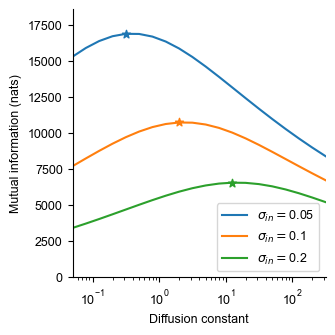

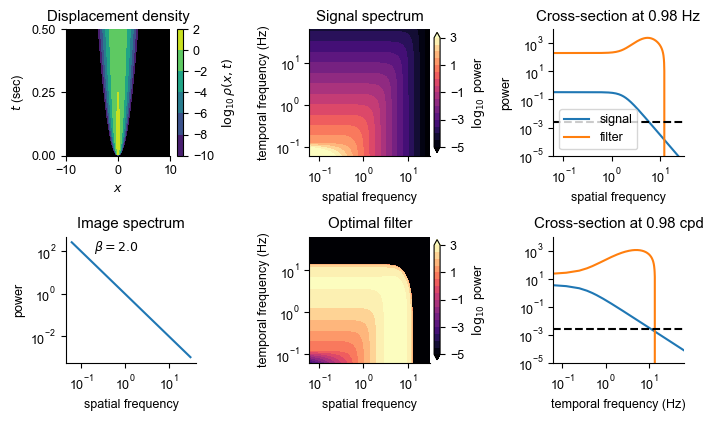

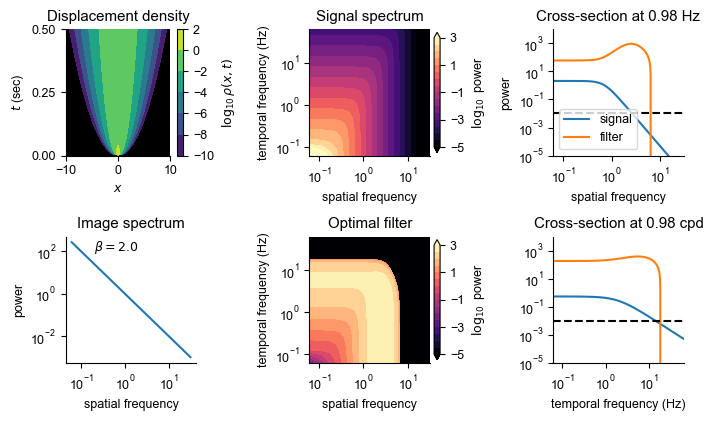

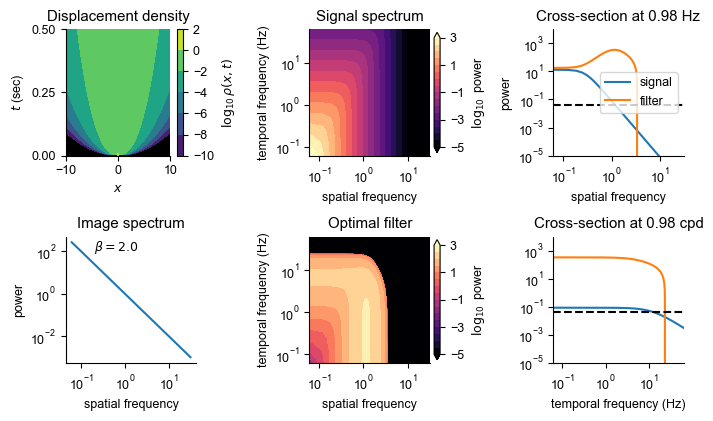

In [6]:
fig,ax = plt.subplots(figsize=(hw,hw))
for i,MI_vals in enumerate(all_MI_vals):
    ax.plot(D_vals, MI_vals, label=rf'$\sigma_{{in}} =${sigma_ins[i]}', color=f'C{i}')
    ax.scatter(D_vals[np.argmax(MI_vals)], np.max(MI_vals),marker="*", color=f'C{i}')
    # ax.text(D_vals[np.argmax(MI_vals)], np.max(MI_vals), f'$\sigma_{{in}} = {sigma_ins[i]}$',horizontalalignment="center")
ax.set_xlabel('Diffusion constant')
ax.set_ylabel('Mutual information (nats)')
ax.set_xscale('log')
ax.set_ylim(0,1.1*np.max(all_MI_vals))
ax.set_xlim(D_vals[0],D_vals[-1])
ax.legend()
plt.tight_layout()
plt.savefig("../results/mutual_information_vs_diffusion_constant.pdf")


for i, MI_vals in enumerate(all_MI_vals):
    Cx, v_opt, MI = mutual_information(k, w, weights, D_vals[np.argmax(MI_vals)], sigma_ins[i], sigma_out, alpha,c=c)
    plot_model(
        Cx, v_opt, sigma_ins[i], sigma_out, K, T, dx, dt, D_vals[np.argmax(MI_vals)], alpha, k, w, w_plot,n=2,levels=np.linspace(-5, 3, 17),beta=2.0, save_path = f"../results/optimal_model_paramters_s_in{sigma_ins[i]}.pdf", ylims=(1e-5,1e4)
    )

/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3549269907.py:55: RuntimeWarning: divide by zero encountered in divide
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3549269907.py:55: RuntimeWarning: invalid value encountered in multiply
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/2213348657.py:56: RuntimeWarning: divide by zero encountered in log10
  z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3549269907.py:55: RuntimeWarning: divide by zero encountered in divide
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3549269907.py:55: RuntimeWarning: invalid value encountered in multiply
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 

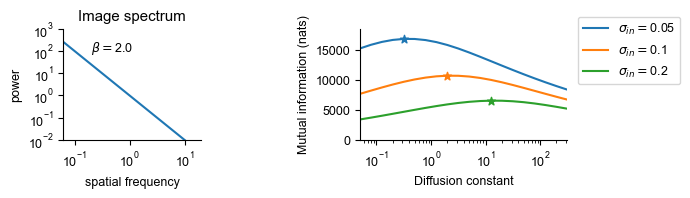

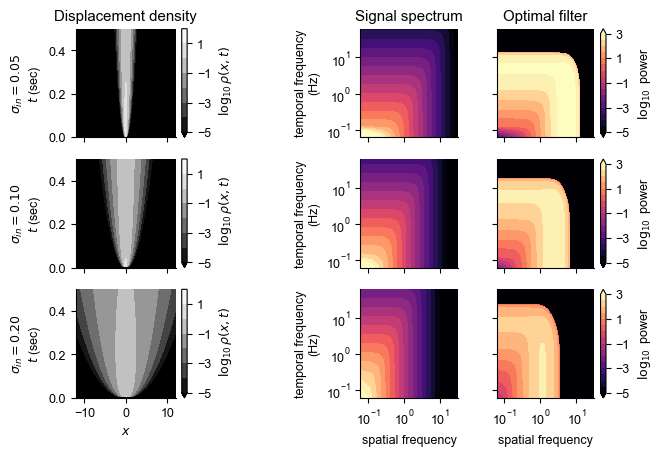

In [181]:
n = 2
levels = np.linspace(-5, 3, 17)

fig, axs = plt.subplots(1, 3, figsize=(fw, 0.6*hw), width_ratios=[2,0.1,3])

# Spectrum on left
ax = axs[0]
ax.plot(k, k**-alpha)
ax.set_xscale("log")
ax.set_yscale("log")
# Only set axis labels/tick labels for left and bottom
ax.set_ylabel("power")
ax.set_xlabel("spatial frequency")
ax.set_title("Image spectrum")
ax.set_ylim(1e-2, 1e3)
ax.set_xlim(k.min(), 2e1)
ax.minorticks_off()
ax.text(2e-1, 1e2, fr"$\beta =${alpha:.1f}")

ax = axs[1]
ax.set_visible(False)

# MI curve on right
ax = axs[2]
for i, MI_vals in enumerate(all_MI_vals):
    ax.plot(D_vals, MI_vals, label=rf'$\sigma_{{in}} =${sigma_ins[i]}', color=f'C{i}')
    ax.scatter(D_vals[np.argmax(MI_vals)], np.max(MI_vals), marker="*", color=f'C{i}')
ax.set_xlabel('Diffusion constant')
# Only leftmost (ax 0) gets y-axis label, so remove from ax 1
ax.set_ylabel('Mutual information (nats)')
ax.set_xscale('log')
ax.set_ylim(0, 1.1 * np.max(all_MI_vals))
ax.set_xlim(D_vals[0], D_vals[-1])
# Only show yticklabels/label on leftmost
ax.legend(ncol=1,loc=(1.05,0.5))
# ax.minorticks_off()
# ax.grid()
plt.tight_layout()
plt.savefig("../results/mutual_information_vs_diffusion_constant.pdf")

# ---- Subplot grid for density & contour plots ----
idxs_to_plot = [0, 1, 2]
fig, axs = plt.subplots(len(idxs_to_plot), 4, figsize=(fw, 1.4 * hw),width_ratios=[1,0.8,1,1])

for i, idx in enumerate(idxs_to_plot):
    D = D_vals[np.argmax(all_MI_vals[idx])]
    sigma_in = sigma_ins[idx]
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    
    # --- Leftmost: Displacement density ---
    ax = axs[i, 0]
    x = np.linspace(-12, 12, 500)
    t = np.linspace(0, 0.5, 100)
    rho = brownian_probability_1d(x[:, None], D, t[None, :])
    ax.set_facecolor("black")
    z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
    cax = ax.contourf(
        x,
        t,
        z,
        levels=np.linspace(-5, 2, 8),
        # rasterized=True,
        extend="min",
        cmap="Greys_r",
    )
    
    # Only leftmost gets y-labels/ticklabels; only bottom gets x-labels
    if i == 0:
        ax.set_title(r'Displacement density')
    if i == len(idxs_to_plot) - 1:
        ax.set_xlabel('$x$')
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(t.min(), t.max())
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel(rf'$\sigma_{{in}} = {sigma_in:.2f}$' + "\n" + r'$t$ (sec)')
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    cbar = fig.colorbar(cax, ax=ax, label='$\\log_{10}\\rho(x,t)$')
    ticks = cbar.ax.get_yticks()
    displayed = ticks[::n] if len(ticks) > n else ticks
    cbar.ax.set_yticks(displayed)

    ax = axs[i, 1]
    ax.set_visible(False)
    # --- Center: Signal spectrum ---
    ax = axs[i, 2]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(Cx).T,
        levels=levels,
        cmap="magma",
        extend="both",
        # rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_ylim(w_plot.min(), w_plot.max())
    if i == 0:
        ax.set_title("Signal spectrum")
    if i == len(idxs_to_plot) - 1:
        ax.set_xlabel("spatial frequency")
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    # Always set y-axis label/ticks for the center plot
    ax.set_ylabel("temporal frequency\n(Hz)")
    # enable ticks for all rows for center plot -- don't blank out!
    # ax.set_yticklabels([]) # Don't do this!
    ax.set_aspect("equal")

    # --- Rightmost: Optimal filter ---
    ax = axs[i, 3]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(v_opt + 1e-22).T,
        levels=levels,
        cmap="magma",
        extend="both",
        # rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_ylim(w_plot.min(), w_plot.max())
    if i == 0:
        ax.set_title("Optimal filter")
    if i == len(idxs_to_plot) - 1:
        ax.set_xlabel("spatial frequency")
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    # Only leftmost column gets y labels/ticklabels
    if ax.get_subplotspec().is_first_col():
        ax.set_ylabel("")
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    cbar = plt.colorbar(cf, ax=ax, label="$\\log_{10}$ power")
    ticks = cbar.ax.get_yticks()
    displayed = ticks[::n] if len(ticks) > n else ticks
    cbar.ax.set_yticks(displayed)
    ax.set_aspect("equal")
# plt.tight_layout()
plt.savefig("../results/mutual_information_vs_diffusion_constant_contour_plots.pdf")


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/1171076357.py:93: RuntimeWarning: divide by zero encountered in log10
  ax.semilogx(w_plot, np.log10(v_opt[s_index, :]), color=color, linestyle="--")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/1171076357.py:111: RuntimeWarning: divide by zero encountered in log10
  ax.semilogx(k, np.log10(v_opt[:, t_index]), color=color, linestyle="--")


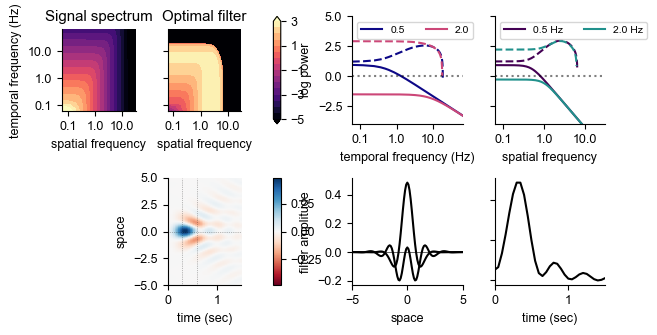

In [182]:
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter

model_idx = 1  # index into sigma_ins / all_MI_vals
n = 2
levels = np.linspace(-5, 3, 17)
t_crosses = [0.5, 2]
s_crosses = [0.5, 2]
ylims = [1e-4, 1e5]
fig_h = 0.6 * hw
cbar_w = 0.1
buffer = 0.1

D = D_vals[np.argmax(all_MI_vals[model_idx])]
sigma_in = sigma_ins[model_idx]
Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)

def plain_log_ticks(ax, axes="xy"):
    axis_list = (ax.xaxis, ax.yaxis) if axes == "xy" else (ax.xaxis,)
    for axis in axis_list:
        fmt = ScalarFormatter()
        fmt.set_scientific(False)
        fmt.set_useOffset(False)
        axis.set_major_formatter(fmt)

w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

fig = plt.figure(figsize=(fw, 1.7 * fig_h))
gs = fig.add_gridspec(
    2, 6,
    width_ratios=[1, 1, cbar_w, buffer, 1.5, 1.5],
    wspace=0.5,
    hspace=0.5,
)

# row 0, col 0: signal spectrum
ax_signal = fig.add_subplot(gs[0, 0])
ax_signal.contourf(
    k,
    w_plot,
    np.log10(Cx).T,
    levels=levels,
    cmap="magma",
    extend="both",
)
ax_signal.set_xscale("log")
ax_signal.set_yscale("log")
ax_signal.minorticks_off()
ax_signal.set_xlim(k.min(), k.max())
ax_signal.set_ylim(w_plot.min(), w_plot.max())
ax_signal.set_xlabel("spatial frequency")
ax_signal.set_ylabel("temporal frequency (Hz)")
ax_signal.set_title("Signal spectrum")
ax_signal.set_aspect("equal")
plain_log_ticks(ax_signal)

# row 0, col 1: optimal filter
ax = fig.add_subplot(gs[0, 1])
cf = ax.contourf(
    k,
    w_plot,
    np.log10(v_opt + 1e-22).T,
    levels=levels,
    cmap="magma",
    extend="both",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.minorticks_off()
ax.set_xlim(k.min(), k.max())
ax.set_xlabel("spatial frequency")
ax.set_ylabel("")
ax.set_title("Optimal filter")
ax.set_aspect("equal")
plain_log_ticks(ax)
ax.set_yticklabels([])

# row 0, col 2: Fourier colorbar
cax = fig.add_subplot(gs[0, 2])
cbar = fig.colorbar(cf, cax=cax)
ticks = cbar.ax.get_yticks()
cbar.ax.set_yticks(ticks[::n] if len(ticks) > n else ticks)

# row 0, col 3: buffer
fig.add_subplot(gs[0, 3]).set_axis_off()

# row 0, col 4: spatial cross-sections
ax = fig.add_subplot(gs[0, 4])
colors_s = mpl.cm.plasma(np.linspace(0, 0.5, len(s_crosses)))
for s_cross, color in zip(s_crosses, colors_s):
    s_index = np.argmin(np.abs(k - s_cross))
    ax.semilogx(w_plot, np.log10(Cx[s_index, :]), color=color, linestyle="-")
    ax.semilogx(w_plot, np.log10(v_opt[s_index, :]), color=color, linestyle="--")
    ax.plot([np.nan], [np.nan], c=color, linestyle="-", label=f"{s_cross:.1f}")
ax.set_xlim(w_plot.min(), w_plot.max())
ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
ax.set_xticks([0.1, 1, 10])
ax.set_xlabel("temporal frequency (Hz)")
ax.set_ylabel("log power")
ax.minorticks_off()
ax.axhline(sigma_in**2, color="k", linestyle=":", alpha=0.5)
ax.legend(fontsize="small", ncol=2, loc="upper left")
plain_log_ticks(ax, axes="x")

# row 0, col 5: temporal cross-sections
ax = fig.add_subplot(gs[0, 5])
colors_t = mpl.cm.viridis(np.linspace(0, 0.5, len(t_crosses)))
for t_cross, color in zip(t_crosses, colors_t):
    t_index = np.argmin(np.abs(w - t_cross))
    ax.semilogx(k, np.log10(Cx[:, t_index]), color=color, linestyle="-")
    ax.semilogx(k, np.log10(v_opt[:, t_index]), color=color, linestyle="--")
    ax.plot([np.nan], [np.nan], c=color, linestyle="-", label=f"{t_cross:.1f} Hz")
ax.set_xlim(k.min(), k.max())
ax.set_xticks([0.1, 1, 10])
ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
ax.set_xlabel("spatial frequency")
ax.axhline(sigma_in**2, color="k", linestyle=":", alpha=0.5)
ax.minorticks_off()
ax.legend(fontsize="small", ncol=2, loc="upper left")
plain_log_ticks(ax)
ax.set_yticklabels([])

# row 1, col 0: empty
fig.add_subplot(gs[1, 0]).set_axis_off()

# row 1, col 1: space-time filter
ax_st = fig.add_subplot(gs[1, 1])
im = ax_st.imshow(
    w_xt_plot,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x[0], x[-1]],
    cmap="RdBu",
    vmin=-np.max(np.abs(w_xt_plot)),
    vmax=np.max(np.abs(w_xt_plot)),
)
ax_st.set_xlabel("time (sec)")
ax_st.set_ylabel("space")
ax_st.set_xlim([0, 1.5])
ax_st.set_ylim([-5, 5])
ax_st.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

# row 1, col 2: space-time colorbar
cax = fig.add_subplot(gs[1, 2])
fig.colorbar(im, cax=cax)

# row 1, col 3: buffer
fig.add_subplot(gs[1, 3]).set_axis_off()

# row 1, col 4: spatial slices
ax_slice = fig.add_subplot(gs[1, 4])
arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
plot_slices = [arg_slice, arg_slice + 6]
for s in plot_slices:
    spatial_slice = w_xt_plot[:, s]
    ax_st.axvline(t[s], color="k", alpha=0.5, linestyle=":", linewidth=0.5)
    ax_slice.plot(x, spatial_slice,c="k")
    ax_slice.axhline(0, color="k", alpha=0.5, linewidth=0.5)
ax_slice.set_xlim([-5, 5])
ax_slice.set_xlabel("space")
ax_slice.set_ylabel("filter amplitude")

# row 1, col 5: temporal slice
ax = fig.add_subplot(gs[1, 5])
ax.plot(t, w_xt_plot[w_xt_plot.shape[0] // 2, :],c="k")
ax.set_xlabel("time (sec)")
ax.set_xlim([0, 1.5])
ax.set_yticklabels([])

plt.savefig(f"../results/model_s_in{sigma_in:.2f}_filter_and_kernels.pdf")


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/1354145135.py:100: RuntimeWarning: divide by zero encountered in log10
  arr = np.log10(v_opt[s_index, :])
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/1354145135.py:122: RuntimeWarning: divide by zero encountered in log10
  arr = np.log10(v_opt[:, t_index])


0.010000000000000002


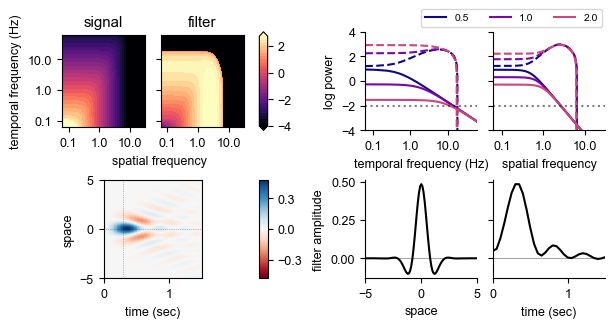

In [73]:
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter

model_idx = 1  # index into sigma_ins / all_MI_vals
n = 2
levels = np.arange(-4, 3, 0.25)
t_crosses = [0.5, 1, 2, ]
s_crosses = [0.5, 1, 2, ]
ylims = [1e-4, 1e4]
fig_h = 0.55 * hw
cbar_w = 0.1
buffer = 0.8
cmap = "magma"

D = D_vals[np.argmax(all_MI_vals[model_idx])]
sigma_in = sigma_ins[model_idx]
Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)

def plain_log_ticks(ax, axes="xy"):
    axis_list = (ax.xaxis, ax.yaxis) if axes == "xy" else (ax.xaxis,)
    for axis in axis_list:
        fmt = ScalarFormatter()
        fmt.set_scientific(False)
        fmt.set_useOffset(False)
        axis.set_major_formatter(fmt)

w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

fig = plt.figure(figsize=(fw, 1.7 * fig_h))
gs = fig.add_gridspec(
    2, 6,
    width_ratios=[1, 1, cbar_w, buffer, 1.35, 1.35],
    wspace=0.2,
    hspace=0.5,
)

# row 0, col 0: signal spectrum
ax_signal = fig.add_subplot(gs[0, 0])
ax_signal.contourf(
    k,
    w_plot,
    np.log10(Cx).T,
    levels=levels,
    cmap=cmap,
    extend="both",
)
# ax_signal.plot(k,D*k**2,c="k",linestyle="--")
ax_signal.set_xscale("log")
ax_signal.set_yscale("log")
ax_signal.minorticks_off()
ax_signal.set_xlim(k.min(), k.max())
ax_signal.set_ylim(w_plot.min(), w_plot.max())
ax_signal.set_xlabel(32*" "+"spatial frequency")
ax_signal.set_ylabel("temporal frequency (Hz)")
ax_signal.set_title("signal")
ax_signal.set_aspect("equal")
ax_signal.spines["right"].set_visible(True)
ax_signal.spines["top"].set_visible(True)
plain_log_ticks(ax_signal)

# row 0, col 1: optimal filter
ax = fig.add_subplot(gs[0, 1])
cf = ax.contourf(
    k,
    w_plot,
    np.log10(v_opt + 1e-22).T,
    levels=levels,
    cmap=cmap,
    extend="both",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.minorticks_off()
ax.set_xlim(k.min(), k.max())
# ax.set_xlabel("spatial frequency")
ax.set_ylabel("")
ax.set_title("filter")
ax.set_aspect("equal")
ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(True)
plain_log_ticks(ax)
ax.set_yticklabels([])

# row 0, col 2: Fourier colorbar
cax = fig.add_subplot(gs[0, 2])
cbar = fig.colorbar(cf, cax=cax)
cbar.ax.set_yticks([-4, -2, 0, 2])
# ticks = cbar.ax.get_yticks()
# cbar.ax.set_yticks(ticks[::n] if len(ticks) > n else ticks)

# row 0, col 3: buffer
fig.add_subplot(gs[0, 3]).set_axis_off()

# row 0, col 4: spatial cross-sections
ax = fig.add_subplot(gs[0, 4])
colors_s = mpl.cm.plasma(np.linspace(0, 0.5, len(s_crosses)))
for s_cross, color in zip(s_crosses, colors_s):
    s_index = np.argmin(np.abs(k - s_cross))
    ax.semilogx(w_plot, np.log10(Cx[s_index, :]), color=color, linestyle="-")
    arr = np.log10(v_opt[s_index, :])
    arr[np.isneginf(arr)] = -10
    ax.semilogx(w_plot, arr, color=color, linestyle="--")
    ax.plot([np.nan], [np.nan], c=color, linestyle="-", label=f"{s_cross:.1f}")
ax.set_xlim(w_plot.min(), w_plot.max())
ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
ax.set_xticks([0.1, 1, 10])
ax.set_xlabel("temporal frequency (Hz)")
ax.set_ylabel("log power")
ax.set_yticks([-4, -2, 0, 2, 4])
ax.minorticks_off()
ax.axhline(np.log10(sigma_in**2), color="k", linestyle=":", alpha=0.5)
print(sigma_in**2)
ax.legend(fontsize="small", ncol=3, loc=(0.5,1.05))
plain_log_ticks(ax, axes="x")

# row 0, col 5: temporal cross-sections
ax = fig.add_subplot(gs[0, 5])
colors_t = colors_s #mpl.cm.viridis(np.linspace(0, 0.5, len(t_crosses)))
for t_cross, color in zip(t_crosses, colors_t):
    t_index = np.argmin(np.abs(w - t_cross))
    ax.semilogx(k, np.log10(Cx[:, t_index]), color=color, linestyle="-")
    arr = np.log10(v_opt[:, t_index])
    arr[np.isneginf(arr)] = -10
    ax.semilogx(k, arr, color=color, linestyle="--")
    ax.plot([np.nan], [np.nan], c=color, linestyle="-", label=f"{t_cross:.1f}")
ax.set_xlim(k.min(), k.max())
ax.set_xticks([0.1, 1, 10])
ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
ax.set_yticks([-4, -2, 0, 2, 4])
ax.set_xlabel("spatial frequency")
ax.axhline(np.log10(sigma_in**2), color="k", linestyle=":", alpha=0.5)
ax.minorticks_off()
# ax.legend(fontsize="small", ncol=2,)
plain_log_ticks(ax)
ax.set_yticklabels([])

# row 1, col 0: empty
fig.add_subplot(gs[1, 0]).set_axis_off()

# row 1, col 1: space-time filter
ax_st = fig.add_subplot(gs[1, :2])
im = ax_st.imshow(
    w_xt_plot,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x[0], x[-1]],
    cmap="RdBu",
    vmin=-np.max(np.abs(w_xt_plot)),
    vmax=np.max(np.abs(w_xt_plot)),
)
ax_st.set_xlabel("time (sec)")
ax_st.set_ylabel("space")
ax_st.spines["right"].set_visible(True)
ax_st.spines["top"].set_visible(True)
ax_st.set_xlim([0, 1.5])
ax_st.set_ylim([-5, 5])
ax_st.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)
ax_st.set_aspect(0.15)

# row 1, col 2: space-time colorbar
cax = fig.add_subplot(gs[1, 2])
cb = fig.colorbar(im, cax=cax)
cb.ax.set_yticks([-0.3,0,0.3])

# row 1, col 3: buffer
fig.add_subplot(gs[1, 3]).set_axis_off()

# row 1, col 4: spatial slices
ax_slice = fig.add_subplot(gs[1, 4])
arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
plot_slices = [arg_slice, ]
for s in plot_slices:
    spatial_slice = w_xt_plot[:, s]
    ax_st.axvline(t[s], color="k", alpha=0.5, linestyle=":", linewidth=0.5)
    ax_slice.plot(x, spatial_slice,c="k")
ax_slice.axhline(0, color="k", alpha=0.5, linewidth=0.5)
ax_slice.set_xlim([-5, 5])
ax_slice.set_xlabel("space")
ax_slice.set_ylabel("filter amplitude")
ymin, ymax = ax_slice.get_ylim()

# row 1, col 5: temporal slice
ax = fig.add_subplot(gs[1, 5])
ax.plot(t, w_xt_plot[w_xt_plot.shape[0] // 2, :],c="k")
ax.set_xlabel("time (sec)")
ax.set_xlim([0, 1.5])
ax.set_ylim([ymin,ymax])
ax.set_yticklabels([])
ax.axhline(0, color="k", alpha=0.5, linewidth=0.5)

plt.savefig(f"../results/model_filter_and_kernels.pdf",bbox_inches="tight")


In [189]:
all_MI_vals = []
# sigma_ins  = [0.05, 0.15, 0.45]
sigma_ins = [0.04, 0.12, 0.36]
D_vals = np.logspace(-2, 2, 100)
for i,sigma_in in tqdm(enumerate(sigma_ins)):
    MI_vals = []
    for j,D in enumerate(D_vals):
        Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha,c=c)
        MI_vals.append(MI)
    all_MI_vals.append(MI_vals)

3it [00:14,  4.71s/it]


<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/2475619670.py:49: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")


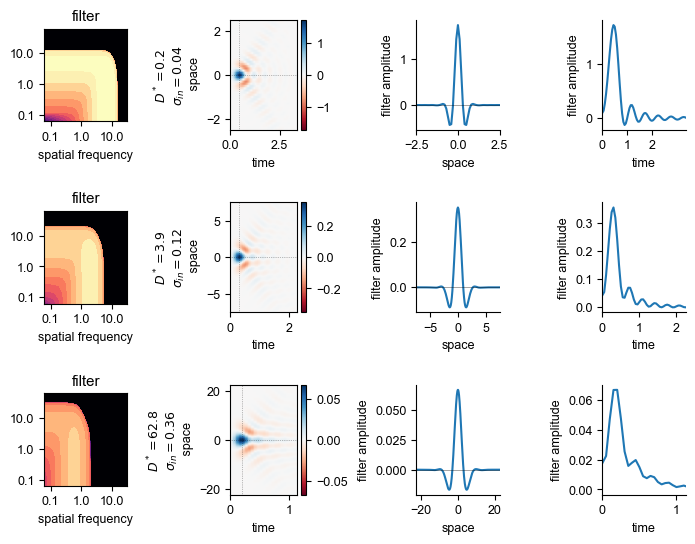

In [190]:
idxs_to_plot = [0, 1, 2]
times = 0.75*np.asarray([4.5,3,1.5])
spaces = np.asarray([2.5,7.5,22.5])

fig, axs = plt.subplots(len(sigma_ins),4,figsize=(fw, 0.8*fw))

for i, idx in enumerate(idxs_to_plot):
    D = D_vals[np.argmax(all_MI_vals[idx])]
    if i == 0:
        Dref = D
    sigma_in = sigma_ins[idx]
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    ax = axs[i,0]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(v_opt + 1e-22).T,
        levels=levels,
        cmap="magma",
        extend="both",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("")
    ax.set_title("filter")
    ax.set_aspect("equal")
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    plain_log_ticks(ax)
        

    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)
    ax = axs[i,1]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        # interpolation="nearest",
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot))
    )
    fig.colorbar(im, ax=ax,)
    ax.set_xlabel(f"time")
    ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")
    ax.set_xlim([0,times[i]])
    ax.set_ylim([-spaces[i],spaces[i]])
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.axhline(0,color="k",alpha=0.5,linestyle=":",linewidth=0.5)


    arg_slice = w_xt_plot[w_xt_plot.shape[0]//2,:].argmax()
    spatial_slice = w_xt_plot[:,arg_slice]
    ax.axvline(t[arg_slice],color="k",alpha=0.5,linestyle=":",linewidth=0.5)
    ax = axs[i,2]
    ax.plot(x,spatial_slice)
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_xlim([-spaces[i],spaces[i]])
    ax.set_xlabel("space")
    ax.set_ylabel("filter amplitude")

    ax = axs[i,3]
    ax.plot(t,w_xt_plot[w_xt_plot.shape[0]//2,:])
    ax.set_xlabel("time")
    ax.set_ylabel("filter amplitude")
    ax.set_xlim([0,times[i]])

    ax.set_xticks([0.,1,2]) if times[i]> 2 else ax.set_xticks([0.,1])
plt.tight_layout()
plt.savefig(f"../results/model_space_time_noise_optima.pdf")

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/1730107371.py:34: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma_{{in}}=$ {sigma_in:.2f}",fontsize=10)


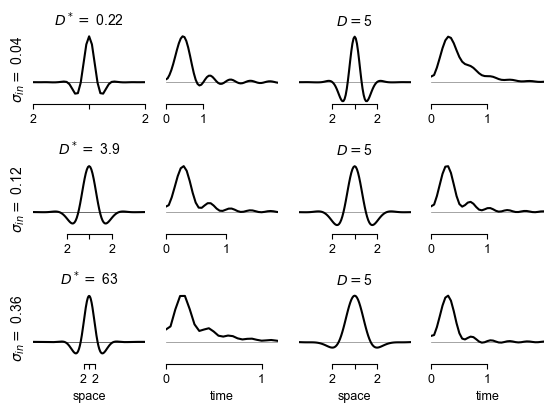

In [ ]:
sigma_ins_tmp = sigma_ins #[0.05,  0.25, 1.0]

fig, axs = plt.subplots(len(sigma_ins_tmp),4,figsize=(0.8*fw, 0.6*fw))

s_t = 1.6
s_s = 
times = np.asarray([3/s_t**0, 3/s_t, 3/s_t**2])
spaces = np.asarray([2,5,20])

ylim_s = [0.1, 0.05,0.03]

for i, sigma_in in enumerate(sigma_ins_tmp):
    
    D = D_vals[np.argmax(all_MI_vals[i])]
    if i == 0:
        Dref = D
    sigma_in = sigma_ins[i]
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)
    arg_slice = w_xt_plot[w_xt_plot.shape[0]//2,:].argmax()
    spatial_slice = w_xt_plot[:,arg_slice]
    ax = axs[i,0]
    ax.plot(x, spatial_slice, c="k")
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_xlim([-spaces[i],spaces[i]])
    XBAR = 2
    ax.spines["bottom"].set_bounds(-XBAR, XBAR)
    ax.set_xticks([-XBAR,0,XBAR])
    ax.set_xticklabels([f"{XBAR:d}","",f"{XBAR:d}"])
    ax.spines["left"].set_visible(False)
    # ax.set_ylim([ymin,ymax])
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    if i == 2:
        ax.set_xlabel("space")
    ax.set_ylabel(f"$\sigma_{{in}}=$ {sigma_in:.2f}",fontsize=10)

    ax.set_yticks([])
    ymin, ymax = ax.get_ylim()
    ax.set_ylim([-ymax*0.45,ymax])
    ymin, ymax = ax.get_ylim()
    ax.set_title(f"$D^* =$ {D:.2g}",fontsize=10)
    # ax.set_ylim([-0.3,0.6])
    # xmin, xmax = ax.get_xlim()
    # ax.plot([xmin,xmin], [0, 0.1], color="k", lw=1.5, solid_capstyle="butt", clip_on=False)

    ax = axs[i,1]
    ax.plot(t, w_xt_plot[w_xt_plot.shape[0]//2,:], c="k")
    if i == 2:
        ax.set_xlabel("time")
    # ax.set_ylabel("filter amplitude")
    ax.spines["left"].set_visible(False)
    ax.set_yticks([])
    # ax.set_xlim([0,times[i]])
    # ax.set_xticks([0.,times[i]])
    XBAR = 1
    ax.set_xlim([0,times[i]])
    ax.spines["bottom"].set_bounds(0, XBAR)
    ax.set_xticks([0,XBAR])
    ax.spines["left"].set_visible(False)
    ax.set_ylim([ymin,ymax])
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)

    

    
    
    D = 5
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

    arg_slice = w_xt_plot[w_xt_plot.shape[0]//2,:].argmax()
    spatial_slice = w_xt_plot[:,arg_slice]

    ax = axs[i,2]
    ax.plot(x, spatial_slice, c="k")
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_xlim([-5,5])
    XBAR = 2
    ax.spines["bottom"].set_bounds(-XBAR, XBAR)
    ax.set_xticks([-XBAR,0,XBAR])
    ax.set_xticklabels([f"{XBAR:d}","",f"{XBAR:d}"])
    if i ==2:
        ax.set_xlabel("space")
    # ax.set_ylabel("filter amplitude")
    ax.spines["left"].set_visible(False)
    ax.set_yticks([])
    # ax.set_ylim([-0.3,0.6])
    ymin, ymax = ax.get_ylim()
    ax.set_ylim([-ymax*0.45,ymax])
    ymin, ymax = ax.get_ylim()
    ax.set_title(f"$D = ${D:d}",fontsize=10)



    ax = axs[i,3]
    ax.plot(t, w_xt_plot[w_xt_plot.shape[0]//2,:], c="k")
    # ax.set_ylabel("filter amplitude")
    # ymin, ymax = ax.get_ylim()
    ax.spines["left"].set_visible(False)
    # YBAR = ylim_s[i]
    # ax.set_ylim([0,ymax])
    # ax.spines["left"].set_bounds(0, YBAR)
    # ax.set_yticks([0,YBAR])
    ax.set_ylim([ymin,ymax])
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_yticks([])
    # XBAR = 1
    # ax.spines["bottom"].set_bounds(0, XBAR)
    ax.set_xlim([0,2])
    XBAR = 1
    ax.spines["bottom"].set_bounds(0, XBAR)
    ax.set_xticks([0,XBAR])
    ax.set_xticks([0.,1])
    if i ==2:
        ax.set_xlabel("time")
    
    # ax.set_ylim([0,0.6])

plt.tight_layout()
plt.savefig(f"../results/model_space_time_noise_both.pdf")


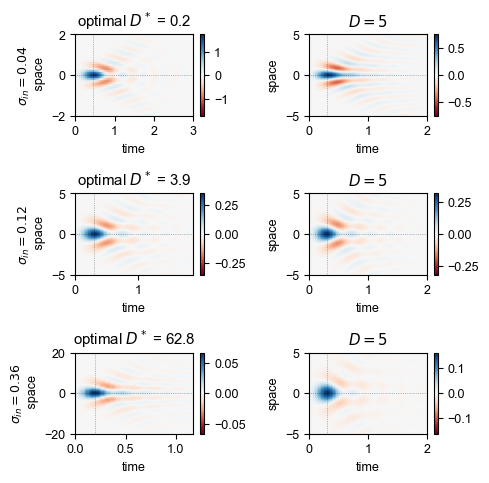

In [154]:
sigma_ins_tmp = sigma_ins  # [0.05,  0.25, 1.0]

fig, axs = plt.subplots(len(sigma_ins_tmp), 2, figsize=(0.7*fw, 0.7 * fw))


for i, sigma_in in enumerate(sigma_ins_tmp):
    sigma_in = sigma_ins[i]

    # --- column 0: optimal D* ---
    D = D_vals[np.argmax(all_MI_vals[i])]
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

    ax = axs[i, 0]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot)),
    )
    fig.colorbar(im, ax=ax)
    ax.set_xlabel("time")
    ax.set_ylabel(f"$\\sigma_{{in}} = {sigma_in:.2f}$\n space")
    ax.set_xlim([0, times[i]])
    ax.set_ylim([-spaces[i], spaces[i]])
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)
    arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
    ax.axvline(t[arg_slice], color="k", alpha=0.5, linestyle=":", linewidth=0.5)
    
    ax.set_title(f"optimal $D^*$ = {D:.1f}")

    # --- column 1: fixed D = 5 ---
    D = 5
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

    ax = axs[i, 1]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot)),
    )
    fig.colorbar(im, ax=ax)
    ax.set_xlabel("time")
    ax.set_ylabel("space")
    ax.set_xlim([0, 2])
    ax.set_ylim([-5, 5])
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)
    arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
    ax.axvline(t[arg_slice], color="k", alpha=0.5, linestyle=":", linewidth=0.5)
    
    ax.set_title(r"$D = 5$")

plt.tight_layout()
plt.savefig(f"../results/model_space_time_noise_both.pdf")


<>:46: SyntaxWarning: invalid escape sequence '\s'
<>:46: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3344167715.py:46: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")


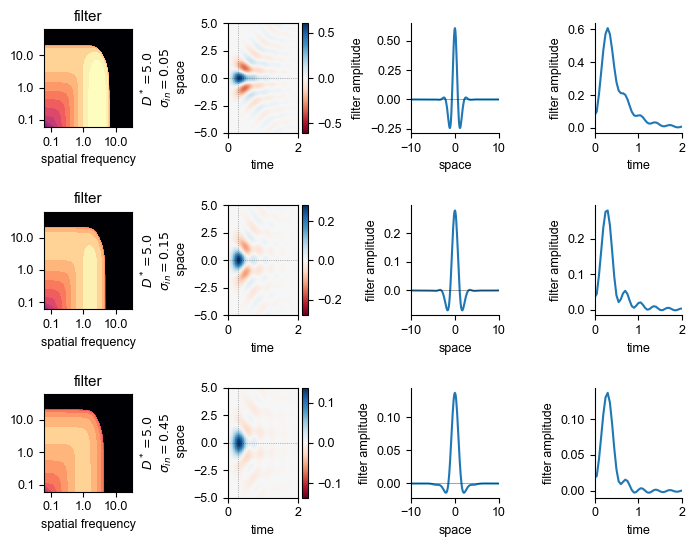

In [119]:
sigma_ins_tmp = sigma_ins #[0.05,  0.25, 1.0]

fig, axs = plt.subplots(len(sigma_ins_tmp),4,figsize=(fw, 0.8*fw))

for i, sigma_in in enumerate(sigma_ins_tmp):
    D = 5

    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)

    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

    ax = axs[i,0]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(v_opt + 1e-22).T,
        levels=levels,
        cmap="magma",
        extend="both",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("")
    ax.set_title("filter")
    ax.set_aspect("equal")
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    plain_log_ticks(ax)

    ax = axs[i,1]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        # interpolation="nearest",
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot))
    )
    fig.colorbar(im, ax=ax,)
    ax.set_xlabel(f"time")
    ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")
    ax.set_xlim([0,2])
    ax.set_ylim([-5,5])
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.axhline(0,color="k",alpha=0.5,linestyle=":",linewidth=0.5)


    arg_slice = w_xt_plot[w_xt_plot.shape[0]//2,:].argmax()
    spatial_slice = w_xt_plot[:,arg_slice]
    ax.axvline(t[arg_slice],color="k",alpha=0.5,linestyle=":",linewidth=0.5)
    ax = axs[i,2]
    ax.plot(x,spatial_slice)
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_xlim([-10,10])
    ax.set_xlabel("space")
    ax.set_ylabel("filter amplitude")

    ax = axs[i,3]
    ax.plot(t,w_xt_plot[w_xt_plot.shape[0]//2,:])
    ax.set_xlabel("time")
    ax.set_ylabel("filter amplitude")
    ax.set_xlim([0,2])
    ax.set_xticks([0.,1,2])

plt.tight_layout()
plt.savefig(f"../results/model_space_time_noise.pdf")

In [57]:
import imageio
import io

sigma_ins_tmp = np.logspace(np.log10(0.05), np.log10(0.8), 20)  # [0.05, 0.2, 0.8]
frames = []

for i, sigma_in in enumerate(sigma_ins_tmp):
    D = 5

    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

    fig, axs = plt.subplots(1, 4, figsize=(fw, 0.8*hw))
    
    # contourf filter
    ax = axs[0]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(v_opt + 1e-22).T,
        levels=np.linspace(levels[0],levels[-1],60),
        cmap="magma",
        extend="both",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("")
    ax.set_title("filter")
    ax.set_aspect("equal")
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    plain_log_ticks(ax)

    # space-time plot
    ax = axs[1]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        # interpolation="nearest",
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot))
    )
    fig.colorbar(im, ax=ax,)
    ax.set_xlabel(f"time")
    ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")
    ax.set_xlim([0,2])
    ax.set_ylim([-5,5])
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

    arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
    spatial_slice = w_xt_plot[:, arg_slice]
    ax.axvline(t[arg_slice], color="k", alpha=0.5, linestyle=":", linewidth=0.5)

    # spatial slice
    ax = axs[2]
    ax.plot(x, spatial_slice)
    ax.axhline(0, color="k", alpha=0.5, linewidth=0.5)
    ax.set_xlim([-10, 10])
    ax.set_xlabel("space")
    ax.set_yticks([-0.1,0,0.1,0.2,0.3,0.4])
    ax.set_ylim([-0.2,0.4])
    ax.set_ylabel("filter amplitude")

    # time slice
    ax = axs[3]
    ax.plot(t, w_xt_plot[w_xt_plot.shape[0] // 2, :])
    ax.set_xlabel("time")
    ax.set_ylabel("filter amplitude")
    ax.set_xlim([0, 2])
    ax.set_xticks([0., 1, 2])
    ax.set_yticks([0,0.1, 0.2,0.3,0.4])
    ax.set_ylim([0,0.4])

    fig.suptitle(f"$\sigma_{{in}}={sigma_in:.2f}$, D={D}")

    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)
    buf.seek(0)
    image = imageio.imread(buf)
    frames.append(image)
    buf.close()

# Save gif
gif_path = "../results/model_space_time_noise.gif"
imageio.mimsave(gif_path, frames, duration=0.75)

print(f"GIF saved to {gif_path}")

<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:82: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:82: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/2968971987.py:51: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/2968971987.py:82: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle(f"$\sigma_{{in}}={sigma_in:.2f}$, D={D}")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/2968971987.py:90: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(buf)


GIF saved to ../results/model_space_time_noise.gif


In [58]:
import imageio
import io

sigma_ins_tmp = np.logspace(np.log10(0.05), np.log10(0.8), 20)  # [0.05, 0.2, 0.8]
frames = []

D_opts = []

for i, sigma_in in enumerate(sigma_ins_tmp):
    results = [
        mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
        for D in D_vals
    ]
    best_idx = np.argmax([r[2] for r in results])
    D = D_vals[best_idx]
    D_opts.append(D)

    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)

    fig, axs = plt.subplots(1, 4, figsize=(fw, 0.8*hw))
    
    # contourf filter
    ax = axs[0]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(v_opt + 1e-22).T,
        levels=np.linspace(levels[0],levels[-1],60),
        cmap="magma",
        extend="both",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("")
    ax.set_title("filter")
    ax.set_aspect("equal")
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    plain_log_ticks(ax)

    # space-time plot
    ax = axs[1]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        # interpolation="nearest",
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot))
    )
    fig.colorbar(im, ax=ax,)
    ax.set_xlabel(f"time")
    ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")
    ax.set_xlim([0,2])
    ax.set_ylim([-5,5])
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)
    ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

    arg_slice = w_xt_plot[w_xt_plot.shape[0] // 2, :].argmax()
    spatial_slice = w_xt_plot[:, arg_slice]
    ax.axvline(t[arg_slice], color="k", alpha=0.5, linestyle=":", linewidth=0.5)

    # spatial slice
    ax = axs[2]
    ax.plot(x, spatial_slice)
    ax.axhline(0, color="k", alpha=0.5, linewidth=0.5)
    ax.set_xlim([-10, 10])
    ax.set_xlabel("space")
    ax.set_yticks([-0.1,0,0.1,0.2,0.3,0.4])
    ax.set_ylim([-0.2,0.4])
    ax.set_ylabel("filter amplitude")

    # time slice
    ax = axs[3]
    ax.plot(t, w_xt_plot[w_xt_plot.shape[0] // 2, :])
    ax.set_xlabel("time")
    ax.set_ylabel("filter amplitude")
    ax.set_xlim([0, 2])
    ax.set_xticks([0., 1, 2])
    ax.set_yticks([0,0.1, 0.2,0.3,0.4])
    ax.set_ylim([0,0.4])

    fig.suptitle(f"$\sigma_{{in}}={sigma_in:.2f}$, D={D}")

    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="png")
    plt.close(fig)
    buf.seek(0)
    image = imageio.imread(buf)
    frames.append(image)
    buf.close()

# Save gif
gif_path = "../results/model_space_time_noise_optimal.gif"
imageio.mimsave(gif_path, frames, duration=0.75)

print(f"GIF saved to {gif_path}")

<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:90: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:90: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3743340669.py:59: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$D^* = {D:.1f}$\n$\sigma_{{in}} = {sigma_in:.2f}$\n space")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3743340669.py:90: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle(f"$\sigma_{{in}}={sigma_in:.2f}$, D={D}")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3743340669.py:98: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(buf)


GIF saved to ../results/model_space_time_noise_optimal.gif


In [32]:
sigma_ins_tmp = np.logspace(np.log10(0.05), np.log10(0.8), 100)  # [0.05, 0.2, 0.8]
frames = []

D_opts = []

for i, sigma_in in tqdm(enumerate(sigma_ins_tmp)):
    results = [
        mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
        for D in D_vals
    ]
    best_idx = np.argmax([r[2] for r in results])
    D = D_vals[best_idx]
    D_opts.append(D)

100it [01:29,  1.12it/s]


powerlaw exponent: 2.53


<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3056272470.py:13: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sigma_{in}$")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3056272470.py:18: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f"Optimal $D^*$ as a function of $\sigma_{{out}}=${sigma_out:.2f}")


Text(0.5, 1.0, 'Optimal $D^*$ as a function of $\\sigma_{out}=$2.00')

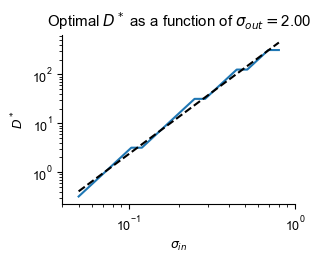

In [62]:
fig,ax = plt.subplots()
ax.plot(sigma_ins_tmp, np.asarray(D_opts))

from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(np.log10(sigma_ins_tmp), np.log10(D_opts))
print(f"powerlaw exponent: {slope:.2f}")
ax.plot(
    sigma_ins_tmp,
    10**(intercept)*sigma_ins_tmp**slope,
    c="k",
    linestyle="--",
)
ax.set_xlabel("$\sigma_{in}$")
ax.set_ylabel("$D^*$")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(0.04,1)
ax.set_title(f"Optimal $D^*$ as a function of $\sigma_{{out}}=${sigma_out:.2f}")

1.9952623149688788


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/199155385.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


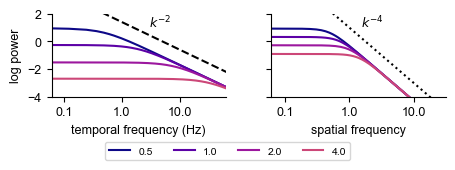

In [124]:
from re import A
import matplotlib as mpl

t_crosses = [0.5, 1, 2, 4]
s_crosses = [0.5, 1, 2, 4]

idx = 1
D = D_vals[np.argmax(all_MI_vals[idx])]
sigma_in = sigma_ins[idx]
Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)

ylims = [1e-4, 1e2]
fig, axs = plt.subplots(1, 3, figsize=(0.66*fw, 0.45*hw), width_ratios=[2, 0.1, 2], constrained_layout=True)

# For temporal frequency (varying w, fixed k; plot along k axis)
ax = axs[2]
# colors_t = mpl.cm.viridis(np.linspace(0, 0.5, len(t_crosses)))
colors_s = mpl.cm.plasma(np.linspace(0, 0.5, len(s_crosses)))
colors_t = colors_s
# ax.plot([np.nan],[np.nan],c="k",linestyle="-",label="signal")
# ax.plot([np.nan],[np.nan],c="k",linestyle="--",label="filter")
for i, (t_cross, color) in enumerate(zip(t_crosses, colors_t)):
    t_index = np.argmin(np.abs(w-t_cross))
    # ax.loglog(k, Cx[:, t_index], label=f"signal {w[t_index]:.1f} Hz", color=color, linestyle="-")
    # ax.loglog(k, v_opt[:, t_index], label=f"filter {w[t_index]:.1f} Hz", color=color, linestyle="--")
    ax.semilogx(k, np.log10(Cx[:, t_index]), color=color, linestyle="-")
    # ax.loglog(k, v_opt[:, t_index], color=color, linestyle="--")
    ax.plot([np.nan],[np.nan],c=color,linestyle="-",label=f"{t_cross:.1f}")
# ax.semilogx(k, np.log10(10*k**-2), c="k", linestyle="--")
ax.semilogx(k, np.log10(10*k**-4), c="k", linestyle=":")
ax.text(1.5, np.log10(10*1**-4), "$k^{-4}$")
ax.set_xlim(k.min(), k.max())
ax.set_xticks([0.1, 1, 10])
if ylims is not None:
    ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
ax.set_xlabel("spatial frequency")
# ax.axhline(sigma_in**2, color="k", linestyle=":",alpha=0.5)
ax.minorticks_off()
# ax.legend(fontsize="small",ncol=4)#,ncol=2,loc="upper left")
# ax.set_title(f"Temporal cross-sections")
plain_log_ticks(ax)
ax.set_yticklabels([])
# Remove/blank center
ax = axs[1]
ax.set_visible(False)

# For spatial frequency (varying k, fixed w; plot along w axis)
ax = axs[0]
colors_s = mpl.cm.plasma(np.linspace(0, 0.5, len(s_crosses)))
# ax.plot([np.nan],[np.nan],c="k",linestyle="-",label="signal")
# ax.plot([np.nan],[np.nan],c="k",linestyle="--",label="filter")
for i, (s_cross, color) in enumerate(zip(s_crosses, colors_s)):
    s_index = np.argmin(np.abs(k-s_cross))
    # ax.loglog(w_plot, Cx[s_index, :], label=f"signal {k[s_index]:.1f} cpd", color=color, linestyle="-")
    # ax.loglog(w_plot, v_opt[s_index, :], label=f"filter {k[s_index]:.1f} cpd", color=color, linestyle="--")
    ax.semilogx(w_plot, np.log10(Cx[s_index, :]), color=color, linestyle="-")
    # ax.loglog(w_plot, v_opt[s_index, :], color=color, linestyle="--")
    # ax.plot([np.nan],[np.nan],c=color,linestyle="-",label=f"{s_cross:.1f}")
ax.semilogx(5*k, np.log10(k**-2), c="k", linestyle="--")
ax.text(3, np.log10(10*1**-2), "$k^{-2}$")
# ax.semilogx(k, np.log10(10*k**-4), c="k", linestyle=":")
ax.set_xlim(w_plot.min(), w_plot.max())
if ylims is not None:
    ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
plain_log_ticks(ax)
ax.set_xticks([0.1, 1, 10])
ax.minorticks_off()
ax.set_xlabel("temporal frequency (Hz)")
ax.set_ylabel("log power")
# ax.legend(fontsize="small",ncol=4,bbox_to_anchor=(1,1.3))
fig.legend(loc='lower center',fontsize="small",ncol=4, bbox_to_anchor=(0.5, -0.1))
# ax.set_title(f"Spatial cross-sections")
# ax.axhline(sigma_in**2, color="k", linestyle=":", alpha=0.5)
# ax.legend(fontsize="small",ncol=2,loc="upper left")
print(D)
plt.tight_layout()
plt.savefig("../results/cross_sections_at_t_and_k.pdf",bbox_inches="tight")

# ax.set_xlim(k.min(), k.max())
# ax.set_xticks([0.1, 1, 10])
# ax.set_ylim(np.log10(ylims[0]), np.log10(ylims[1]))
# ax.set_xlabel("spatial frequency")
# ax.axhline(sigma_in**2, color="k", linestyle=":", alpha=0.5)
# ax.minorticks_off()
# ax.legend(fontsize="small", ncol=2, loc="upper left")
# plain_log_ticks(ax)

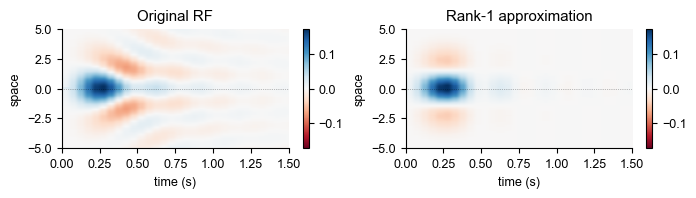

In [627]:
U,S, Vh = np.linalg.svd(w_xt_plot)

# SVD
U, S, Vt = np.linalg.svd(w_xt_plot, full_matrices=False)

# Rank-k approximation
rank = 1
W_k = (U[:, :rank] * S[:rank]) @ Vt[:rank, :]

fig, axs = plt.subplots(1, 2, figsize=(fw, 0.6 * hw))

vmax = np.max(np.abs(w_xt_plot))

# Original
ax = axs[0]
im = ax.imshow(
    w_xt_plot,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x[0], x[-1]],
    cmap="RdBu",
    vmin=-vmax,
    vmax=vmax,
)
fig.colorbar(im, ax=ax)
ax.set_title("Original RF")
ax.set_xlabel("time (s)")
ax.set_ylabel("space")
ax.set_xlim([0, 1.5])
ax.set_ylim([-5, 5])
ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

# Rank-k approximation
ax = axs[1]
im = ax.imshow(
    W_k,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x[0], x[-1]],
    cmap="RdBu",
    vmin=-vmax,
    vmax=vmax,
)
fig.colorbar(im, ax=ax)
ax.set_title(f"Rank-{rank} approximation")
ax.set_xlabel("time (s)")
ax.set_ylabel("space")
ax.set_xlim([0, 1.5])
ax.set_ylim([-5, 5])
ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

plt.tight_layout()

<>:57: SyntaxWarning: invalid escape sequence '\l'
<>:91: SyntaxWarning: invalid escape sequence '\l'
<>:57: SyntaxWarning: invalid escape sequence '\l'
<>:91: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/334903483.py:57: SyntaxWarning: invalid escape sequence '\l'
  cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/334903483.py:91: SyntaxWarning: invalid escape sequence '\l'
  cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")


min,max temporal frequency: 0.31, 157.08
min,max spatial frequency: 0.12, 62.83


0it [00:00, ?it/s]

/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/334903483.py:37: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/334903483.py:72: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(
3it [00:00,  3.99it/s]


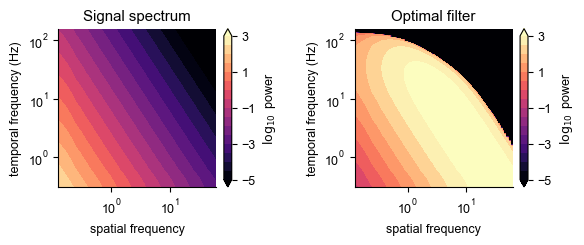

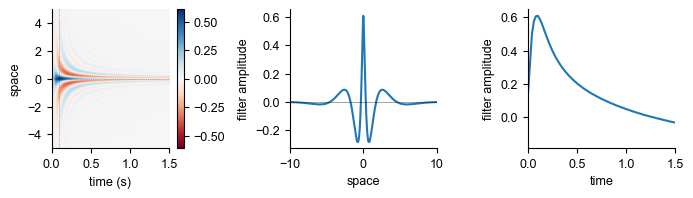

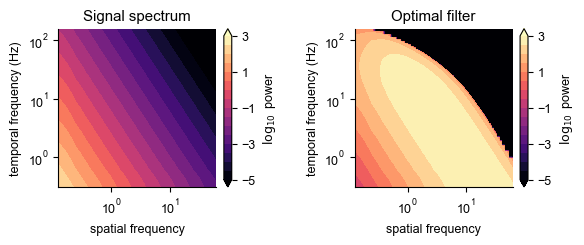

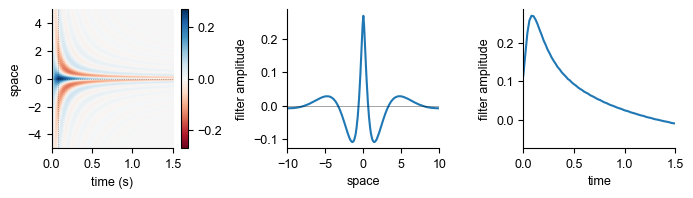

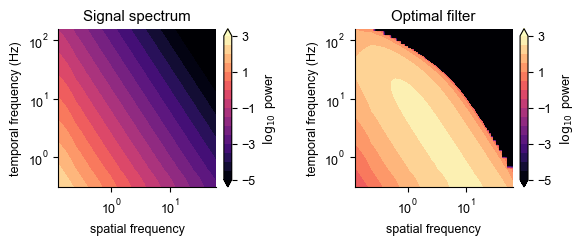

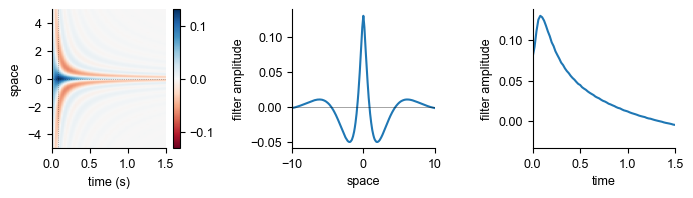

In [ ]:
sigma_in  = 0.1
sigma_out = 2.0
K         = 1020
T         = 1024
dx        = 0.05
dt        = 0.02
D         = 5
alpha     = 2.0
c         = 0.001

# One-sided Fourier grids.
# Drop spatial DC because C_s(k) = k^{-alpha} diverges at k = 0.
k = 2 * np.pi * np.fft.rfftfreq(K, d=dx)[1:]
w = 2 * np.pi * np.fft.rfftfreq(T, d=dt)[1:]
w_plot = w.copy()
w_plot[0] = w[1] / 2

wk = one_sided_weights(K, drop_dc=True)
ww = one_sided_weights(T, drop_dc=True)

print(f"min,max temporal frequency: {w.min():.2f}, {w.max():.2f}")
print(f"min,max spatial frequency: {k.min():.2f}, {k.max():.2f}")

weights = wk[:, None] * ww[None, :]
N_eff = np.sum(weights)

levels = np.linspace(-5, 3, 17)
ylims = (1e-5,1e4)

sigma_ins  = [0.05, 0.1, 0.2]
for i,sigma_in in tqdm(enumerate(sigma_ins)):
    MI_vals = []    
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha,c=c,separable=True)
    
    fig,axs = plt.subplots(1,2,figsize=(fw, 0.6*hw))
    ax = axs[0]
    cf = ax.contourf(
        k, 
        w_plot, 
        np.log10(Cx).T, 
        levels=levels, 
        # norm=mpl.colors.LogNorm(vmin=levels[0], vmax=levels[-1]), 
        cmap="magma",
        extend="both", 
        rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(),k.max())
    ax.set_ylim(w.min(),w.max())
    # ax.set_xlim(f_min if f_min is not None else f.min(), f_max if f_max is not None else f.max())
    # ax.set_ylim(tf_min_hz if tf_min_hz is not None else tf_plot.min(), tf_max_hz if tf_max_hz is not None else tf_plot.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("temporal frequency (Hz)")
    ax.set_title("Signal spectrum")
    cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")
    # Format: label every other tick only
    ticks = cbar.ax.get_yticks()
    # Only keep every other tick; preserve final tick to capture vmax if not even
    displayed = ticks[::n] if len(ticks) > n else ticks
    # Set which ticks to show labels for (hide the in-between)
    cbar.ax.set_yticks(displayed)
    ax.set_aspect("equal")
    # cbar.ax.set_yticklabels([f"{tick:.2e}" for tick in displayed])


    ax = axs[1]
    # levels = np.linspace(-3,1,10)
    cf = ax.contourf(
        k, 
        w_plot, 
        np.log10(v_opt+1e-22).T, 
        levels=levels, 
        # norm=mpl.colors.LogNorm(vmin=levels[0], vmax=levels[-1]), 
        cmap="magma",
        extend="both", 
        rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    # ax.set_xlim(f_min if f_min is not None else f.min(), f_max if f_max is not None else f.max())
    # ax.set_ylim(tf_min_hz if tf_min_hz is not None else tf_plot.min(), tf_max_hz if tf_max_hz is not None else tf_plot.max())
    ax.set_xlim(k.min(),k.max())
    ax.set_xlabel("spatial frequency")
    ax.set_ylabel("temporal frequency (Hz)")
    ax.set_title("Optimal filter")
    cbar = plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.03,label="$\log_{10}$ power")
    # Format: label every other tick only
    ticks = cbar.ax.get_yticks()
    # Only keep every other tick; preserve final tick to capture vmax if not even
    displayed = ticks[::n] if len(ticks) > n else ticks
    # Set which ticks to show labels for (hide the in-between)
    cbar.ax.set_yticks(displayed)
    # cbar.ax.set_yticklabels([f"{tick:.2e}" for tick in displayed])
    ax.set_aspect("equal")

    if w[0] > 0: v_opt = np.pad(v_opt, ((0,0),(1,0)), mode='constant')
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)




    fig, axs = plt.subplots(1,3,figsize=(fw, 0.6*hw))
    ax = axs[0]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        # interpolation="nearest",
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot))
    )
    fig.colorbar(im, ax=ax,)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("space")
    ax.set_xlim([0,1.5])
    ax.set_ylim([-5,5])
    ax.axhline(0,color="k",alpha=0.5,linestyle=":",linewidth=0.5)


    arg_slice = w_xt_plot[w_xt_plot.shape[0]//2,:].argmax()
    spatial_slice = w_xt_plot[:,arg_slice]
    ax.axvline(t[arg_slice],color="k",alpha=0.5,linestyle=":",linewidth=0.5)
    ax = axs[1]
    ax.plot(x,spatial_slice)
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_xlim([-10,10])
    ax.set_xlabel("space")
    ax.set_ylabel("filter amplitude")

    ax = axs[2]
    ax.plot(t,w_xt_plot[w_xt_plot.shape[0]//2,:])
    ax.set_xlabel("time")
    ax.set_ylabel("filter amplitude")
    ax.set_xlim([0,1.5])

    plt.tight_layout()

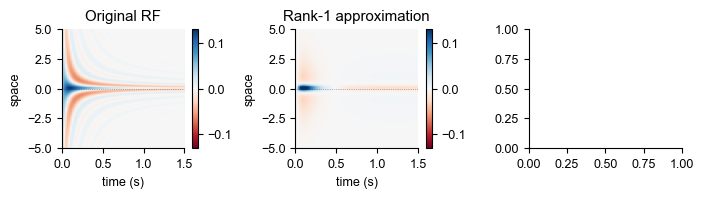

In [543]:
U,S, Vh = np.linalg.svd(w_xt_plot)

# SVD
U, S, Vt = np.linalg.svd(w_xt_plot, full_matrices=False)

# Rank-k approximation
rank = 1
W_k = (U[:, :rank] * S[:rank]) @ Vt[:rank, :]

fig, axs = plt.subplots(1, 3, figsize=(fw, 0.6 * hw))

vmax = np.max(np.abs(w_xt_plot))

# Original
ax = axs[0]
im = ax.imshow(
    w_xt_plot,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x[0], x[-1]],
    cmap="RdBu",
    vmin=-vmax,
    vmax=vmax,
)
fig.colorbar(im, ax=ax)
ax.set_title("Original RF")
ax.set_xlabel("time (s)")
ax.set_ylabel("space")
ax.set_xlim([0, 1.5])
ax.set_ylim([-5, 5])
ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

# Rank-k approximation
ax = axs[1]
im = ax.imshow(
    W_k,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], x[0], x[-1]],
    cmap="RdBu",
    vmin=-vmax,
    vmax=vmax,
)
fig.colorbar(im, ax=ax)
ax.set_title(f"Rank-{rank} approximation")
ax.set_xlabel("time (s)")
ax.set_ylabel("space")
ax.set_xlim([0, 1.5])
ax.set_ylim([-5, 5])
ax.axhline(0, color="k", alpha=0.5, linestyle=":", linewidth=0.5)

plt.tight_layout()

In [521]:
Cx

array([[2.63536399e+28, 1.22443495e+03, 4.97275109e+02, ...,
        3.69908650e-01, 3.68967867e-01, 3.68031309e-01],
       [6.58840997e+27, 3.06108736e+02, 1.24318777e+02, ...,
        9.24771625e-02, 9.22419668e-02, 9.20078273e-02],
       [2.92818221e+27, 1.36048327e+02, 5.52527899e+01, ...,
        4.11009611e-02, 4.09964297e-02, 4.08923677e-02],
       ...,
       [1.02120559e+23, 4.74469490e-03, 1.92694490e-03, ...,
        1.43339889e-06, 1.42975334e-06, 1.42612418e-06],
       [1.01719693e+23, 4.72607002e-03, 1.91938085e-03, ...,
        1.42777220e-06, 1.42414097e-06, 1.42052605e-06],
       [1.01321184e+23, 4.70755458e-03, 1.91186124e-03, ...,
        1.42217859e-06, 1.41856158e-06, 1.41496082e-06]], shape=(510, 513))

In [500]:
# Temporal kernels at each positive spatial frequency k.
h_k_t = np.fft.irfft(H_k_w, n=T, axis=1).real  # shape: (len(k), T)

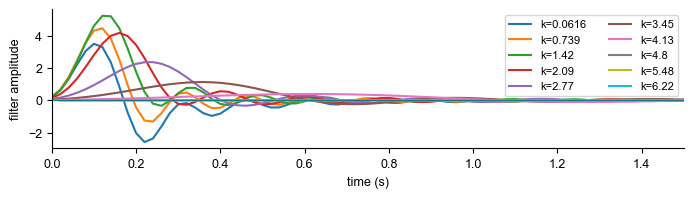

In [501]:
fig, ax = plt.subplots(figsize=(fw, 0.6 * hw))

for i in np.linspace(0, 100, 10, dtype=int):
    ax.plot(t, h_k_t[i], label=f"k={k[i]:.3g}")

ax.axhline(0, color="k", alpha=0.5, linewidth=0.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("filter amplitude")
ax.set_xlim([0, 1.5])
ax.legend(fontsize=8,ncol=2)

plt.tight_layout()

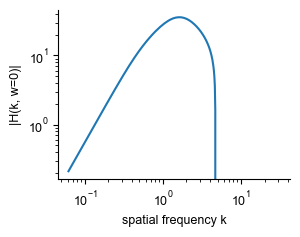

In [441]:
plt.plot(k, amp[:, 0])
plt.xlabel("spatial frequency k")
plt.ylabel("|H(k, w=0)|")
plt.yscale("log")
plt.xscale("log")
plt.show()


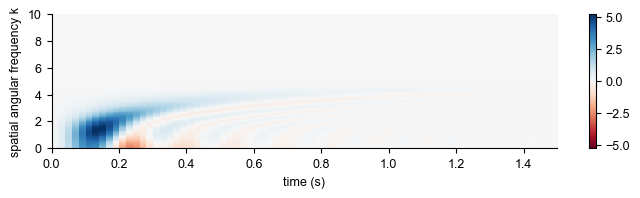

In [434]:
fig, ax = plt.subplots(figsize=(fw, 0.6 * hw))

vmax = np.max(np.abs(h_k_t))

im = ax.imshow(
    h_k_t,
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], k[0], k[-1]],
    interpolation="nearest",
    cmap="RdBu",
    vmin=-vmax,
    vmax=vmax,
)

fig.colorbar(im, ax=ax)
ax.set_xlabel("time (s)")
ax.set_ylabel("spatial angular frequency k")
ax.set_xlim([0, 1.5])
ax.set_ylim([0,10])

plt.tight_layout()
plt.savefig("../results/temporal_kernels_swept_over_k.pdf")

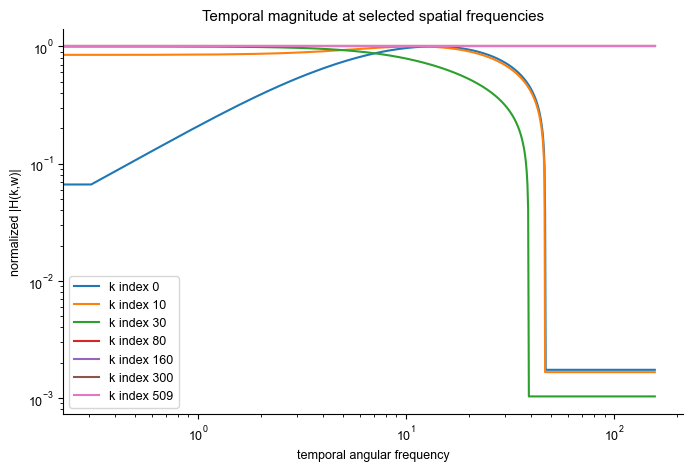

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for i in [0, 10, 30, 80, 160, 300, 509]:
    ax.plot(, amp[i, :] / np.max(amp[i, :]), label=f"k index {i}")


ax.set_xlabel("temporal angular frequency")
ax.set_ylabel("normalized |H(k,w)|")
ax.set_title("Temporal magnitude at selected spatial frequencies")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")


0it [00:00, ?it/s]

3it [00:00,  4.41it/s]


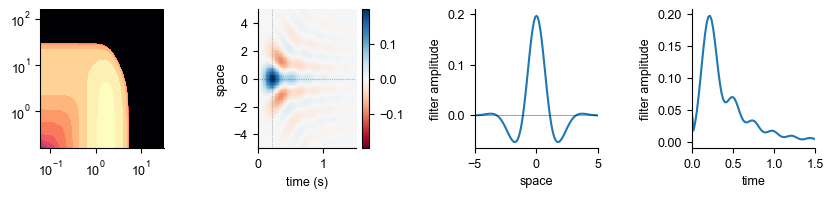

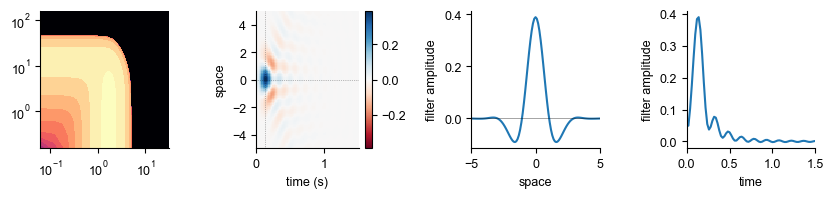

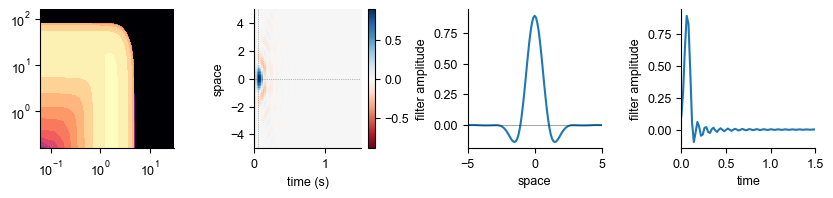

In [ ]:
## loop through eta values (weighting on temporal derivative)

all_MI_vals = []
cs  = [0.05, 0.01, 0.001]
D = 10
sigma_in = 0.1
for i,c in tqdm(enumerate(cs)):
    Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha,c=c)
    w_xt_plot, x, t = compute_space_time_filter(v_opt, T, dt, dx)


    fig, axs = plt.subplots(1,4,figsize=(1.2*fw, 0.6*hw))
    ax = axs[0]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(v_opt + 1e-22).T,
        levels=levels,
        cmap="magma",
        extend="both",
        # rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_ylim(w_plot.min(), w_plot.max())

    ax = axs[1]
    im = ax.imshow(
        w_xt_plot,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x[0], x[-1]],
        interpolation="nearest",
        cmap="RdBu",
        vmin=-np.max(np.abs(w_xt_plot)),
        vmax=np.max(np.abs(w_xt_plot))
    )
    fig.colorbar(im, ax=ax,)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("space")
    ax.set_xlim([0,1.5])
    ax.set_ylim([-5,5])
    ax.axhline(0,color="k",alpha=0.5,linestyle=":",linewidth=0.5)


    arg_slice = w_xt_plot[w_xt_plot.shape[0]//2,:].argmax()
    spatial_slice = w_xt_plot[:,arg_slice]
    ax.axvline(t[arg_slice],color="k",alpha=0.5,linestyle=":",linewidth=0.5)
    ax = axs[2]
    ax.plot(x,spatial_slice)
    ax.axhline(0,color="k",alpha=0.5,linewidth=0.5)
    ax.set_xlim([-5,5])
    ax.set_xlabel("space")
    ax.set_ylabel("filter amplitude")

    ax = axs[3]
    ax.plot(t,w_xt_plot[w_xt_plot.shape[0]//2,:])
    ax.set_xlabel("time")
    ax.set_ylabel("filter amplitude")
    ax.set_xlim([0,1.5])
    plt.tight_layout()
    
    

0it [00:00, ?it/s]

3it [00:03,  1.02s/it]
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/2385814703.py:16: RuntimeWarning: divide by zero encountered in log10
  z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/2385814703.py:17: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cax = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/2385814703.py:45: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/2385814703.py:59: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(w.min(),w.max())
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/2385814703.py:79: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(


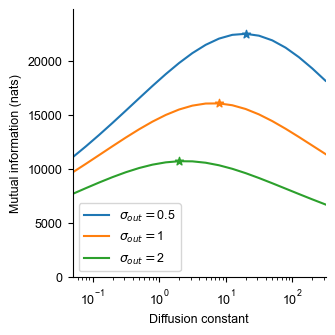

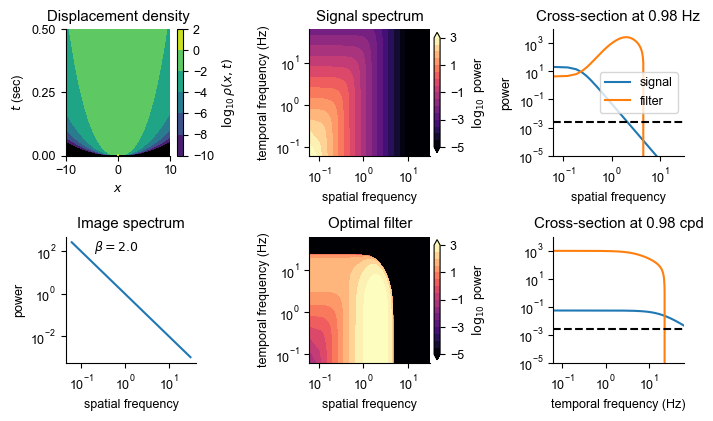

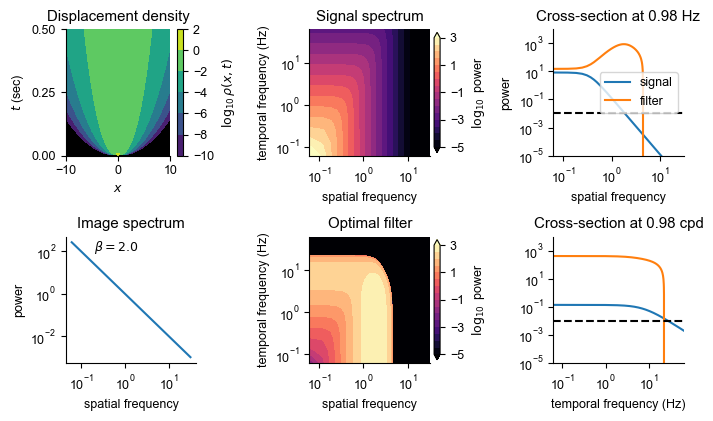

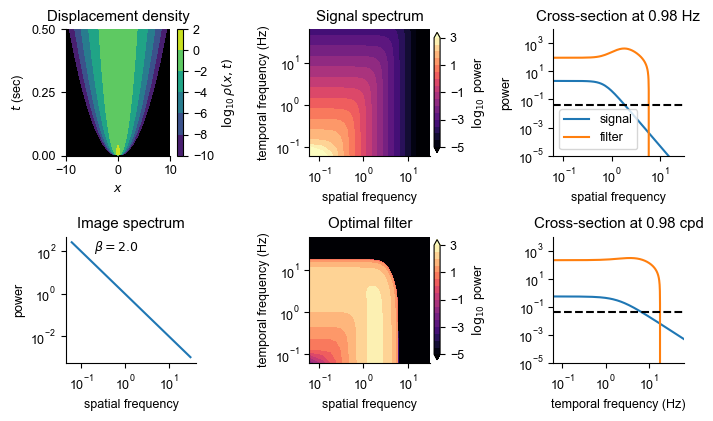

In [628]:
all_MI_vals = []
sigma_outs  = [0.5, 1, 2]
sigma_in = 0.1
D_vals = np.logspace(-1.3, 2.5, 20)


for i,sigma_out in tqdm(enumerate(sigma_outs)):
    MI_vals = []
    for j,D in enumerate(D_vals):
        Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha,c=c)
        MI_vals.append(MI)
    all_MI_vals.append(MI_vals)


fig,ax = plt.subplots(figsize=(hw,hw))
for i,MI_vals in enumerate(all_MI_vals):
    ax.plot(D_vals, MI_vals, label=rf'$\sigma_{{out}} =${sigma_outs[i]}', color=f'C{i}')
    ax.scatter(D_vals[np.argmax(MI_vals)], np.max(MI_vals),marker="*", color=f'C{i}')
    # ax.text(D_vals[np.argmax(MI_vals)], np.max(MI_vals), f'$\sigma_{{in}} = {sigma_ins[i]}$',horizontalalignment="center")
ax.set_xlabel('Diffusion constant')
ax.set_ylabel('Mutual information (nats)')
ax.set_xscale('log')
ax.set_ylim(0,1.1*np.max(all_MI_vals))
ax.set_xlim(D_vals[0],D_vals[-1])
ax.legend()
plt.tight_layout()
# plt.savefig("../results/mutual_information_vs_diffusion_constant.pdf")


for i, MI_vals in enumerate(all_MI_vals):
    Cx, v_opt, MI = mutual_information(k, w, weights, D_vals[np.argmax(MI_vals)], sigma_ins[i], sigma_out, alpha,c=c)
    plot_model(
        Cx, v_opt, sigma_ins[i], sigma_out, K, T, dx, dt, D_vals[np.argmax(MI_vals)], alpha, k, w, w_plot,n=2,levels=np.linspace(-5, 3, 17),beta=2.0, save_path = f"../results/optimal_model_paramters_s_in{sigma_ins[i]}.pdf", ylims=(1e-5,1e4)
    )

In [109]:
all_MI_vals = []
v_opt_list = []
sigma_ins_sweep  = np.logspace(np.log10(0.01), np.log10(0.5), 8)
sigma_outs_sweep = np.logspace(np.log10(0.5), np.log10(4), 8)
D_vals = np.logspace(-1.3, 3, 20)

D_opt = []
for i, sigma_in in tqdm(enumerate(sigma_ins_sweep)):
    for sigma_out in sigma_outs_sweep:
        MI_vals = []
        v_opts = []
        for j, D in enumerate(D_vals):
            Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
            MI_vals.append(MI)
            v_opts.append(v_opt)
        best_idx = np.argmax(MI_vals)
        D_opt.append(D_vals[best_idx])
        v_opt_list.append(v_opts[best_idx])
        all_MI_vals.append(MI_vals)
    

0it [00:00, ?it/s]

8it [00:56,  7.04s/it]


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3791733182.py:6: SyntaxWarning: invalid escape sequence '\s'
  ax.text(D_vals[np.argmax(MI_vals)], np.max(MI_vals)+7e2, f'$\sigma_{{in}} = {sigma_ins[i]}$',horizontalalignment="center")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_58039/3791733182.py:28: SyntaxWarning: invalid escape sequence '\l'
  cbar = plt.colorbar(im, ax=ax, label="optimal $\log D$")


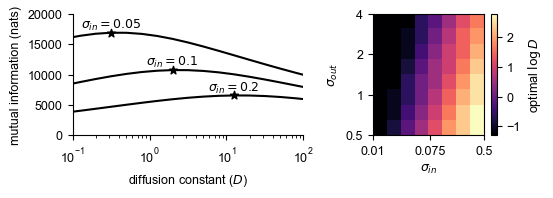

In [114]:
fig, axs = plt.subplots(1,2,figsize=(0.8*fw,0.6*hw),width_ratios=[1,0.6])
ax = axs[0]
for i, MI_vals in enumerate(all_MI_vals):
    ax.plot(D_vals, MI_vals, label=rf'$\sigma_{{in}} =${sigma_ins[i]}', color="k")
    ax.scatter(D_vals[np.argmax(MI_vals)], np.max(MI_vals), marker="*", color="k")
    ax.text(D_vals[np.argmax(MI_vals)], np.max(MI_vals)+7e2, f'$\sigma_{{in}} = {sigma_ins[i]}$',horizontalalignment="center")
ax.set_xlabel('diffusion constant ($D$)')
# Only leftmost (ax 0) gets y-axis label, so remove from ax 1
ax.set_ylabel('mutual information (nats)')
ax.set_xscale('log')
ax.set_ylim(0, 20000)
ax.set_xlim(1e-1, 1e2)
# Only show yticklabels/label on leftmost
# ax.legend(ncol=1,loc=(1.05,0.5))
# ax.legend(ncol=3)
# ax.minorticks_off()
# ax.grid()

D_opt_arr = np.array(D_opt).reshape(len(sigma_ins_sweep), len(sigma_outs_sweep))
ax = axs[1]
im = ax.imshow(
    np.log10(D_opt_arr.T),  # transpose so sigma_in is x axis, sigma_out is y axis
    origin="lower",
    aspect="auto",
    extent=[np.log10(sigma_ins_sweep[0]), np.log10(sigma_ins_sweep[-1]), np.log10(sigma_outs_sweep[0]), np.log10(sigma_outs_sweep[-1])],
    cmap="magma"
)
cbar = plt.colorbar(im, ax=ax, label="optimal $\log D$")
cbar.ax.set_yticks([-1,0,1,2])
ax.set_xlabel(r"$\sigma_{in}$")
ax.set_ylabel(r"$\sigma_{out}$")
# "spines" is an attribute of the Axes object, not YAxis/XAxis. You should use ax.spines["right"] and ax.spines["top"]:
ax.spines["right"].set_visible(True)
ax.spines["top"].set_visible(True)

# Optionally, customize ticks to reflect actual values (base-10 values, not log)
xticks = [0.01, 0.075,  0.5]
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels([f"{x:.2g}" for x in xticks])
yticks = [0.5, 1, 2, 4]
ax.set_yticks(np.log10(yticks))
ax.set_yticklabels([f"{y:.2g}" for y in yticks])

plt.tight_layout()
plt.savefig("../results/optimal_diffusion_constant_vs_input_output_noise.pdf")



In [136]:
np.linspace(0.01,0.4,4)

array([0.01, 0.14, 0.27, 0.4 ])

In [124]:
sigma_outs_sweep

array([0.5       , 0.6729501 , 0.90572366, 1.21901365, 1.64067071,
       2.20817903, 2.97198858, 4.        ])

In [286]:
idx = 1
D = D_vals[np.argmax(all_MI_vals[idx])]
sigma_in = sigma_ins[idx]
print(D,sigma_in)

2.0943662539726753 0.1


2.0943662539726753 0.1 10370.348776247594


3it [00:00, 31.77it/s]

3.5696988468260646 13153.656615466514
6.543189129712966 10739.654946386256
16.237767391887218 7237.694373378849


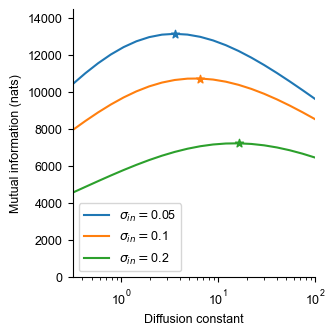

In [289]:
idx = 1
D = D_vals[np.argmax(all_MI_vals[idx])]
sigma_in = sigma_ins[idx]
_, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha, c=c)
print(D,sigma_in,MI)

all_MI_vals_fixed_filter = []
sigma_ins_  = [0.05, 0.1, 0.2]
D_vals_ = np.logspace(-0.5, 2, 20)
for i,sigma_in in tqdm(enumerate(sigma_ins_)):
    MI_vals = []
    for j,D in enumerate(D_vals_):
        Cx = Cx_drift(k, w, D, alpha=alpha)
        noise_floor = sigma_in**2 * v_opt + sigma_out**2
        snr = Cx * v_opt / noise_floor
        MI = 0.5 * np.sum(weights * np.log1p(snr))
        MI_vals.append(MI)
    all_MI_vals_fixed_filter.append(MI_vals)


fig, ax = plt.subplots(figsize=(hw,hw))
for i, MI_vals in enumerate(all_MI_vals_fixed_filter):
    ax.plot(D_vals_, MI_vals, label=rf'$\sigma_{{in}} =${sigma_ins_[i]}', color=f'C{i}')
    ax.scatter(D_vals_[np.argmax(MI_vals)], np.max(MI_vals), marker="*", color=f'C{i}')
    print(D_vals_[np.argmax(MI_vals)], np.max(MI_vals))
ax.set_xlabel('Diffusion constant')
# Only leftmost (ax 0) gets y-axis label, so remove from ax 1
ax.set_ylabel('Mutual information (nats)')
ax.set_xscale('log')
ax.set_ylim(0, 1.1 * np.max(all_MI_vals_fixed_filter))
ax.set_xlim(D_vals_[0], D_vals_[-1])
# Only show yticklabels/label on leftmost
# ax.legend(ncol=1,loc=(1.05,0.5))
ax.legend()
# ax.grid()
# ax.minorticks_off()
plt.tight_layout()
plt.savefig("../results/same_filter_different_noises.pdf")

In [275]:
sigma_ins[idx]

0.1

In [ ]:


for axis in (ax.xaxis, ax.yaxis):
    fmt = ScalarFormatter()
    fmt.set_scientific(False)
    fmt.set_useOffset(False)
    axis.set_major_formatter(fmt)

min,max temporal frequency: 0.00, 62.83
min,max spatial frequency: 0.03, 31.42


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/3549269907.py:55: RuntimeWarning: divide by zero encountered in divide
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/3549269907.py:55: RuntimeWarning: invalid value encountered in multiply
  return 1 / np.sqrt(4 * np.pi * D * t) * np.exp(-x**2 / (4 * D * t))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/3355423427.py:54: RuntimeWarning: divide by zero encountered in log10
  z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/3355423427.py:63: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  c = ax.contour(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_85017/3355423427.py:100: UserWarning: The following kwargs were not used by contour: 'negative_linestyle'
  c = ax.contour(
/var/folders/hy/7cxjc3qx1vsfk45ck

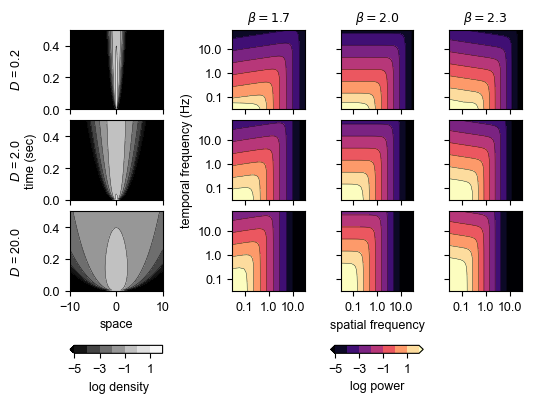

In [144]:
def plot_spatial_temporal_spectra_for_different_betas():

    sigma_in  = 0.1
    sigma_out = 2.0
    K         = 2*1024
    T         = 2*1024
    dx        = 0.1
    dt        = 0.05 #0.05
    D         = 5
    alpha     = 2.0
    c         = 0.04

    # One-sided Fourier grids.
    # Drop spatial DC because C_s(k) = k^{-alpha} diverges at k = 0.
    k = 2 * np.pi * np.fft.rfftfreq(K, d=dx)[1:]
    w = 2 * np.pi * np.fft.rfftfreq(T, d=dt)
    w_plot = w.copy()
    w_plot[0] = w[1] / 2

    wk = one_sided_weights(K, drop_dc=True)
    ww = one_sided_weights(T, drop_dc=False)

    print(f"min,max temporal frequency: {w.min():.2f}, {w.max():.2f}")
    print(f"min,max spatial frequency: {k.min():.2f}, {k.max():.2f}")

    weights = wk[:, None] * ww[None, :]
    N_eff = np.sum(weights)

    betas = [1.7, 2.0, 2.3]
    Ds = [0.2, 2, 20]

    ncols = 2 + len(betas)
    nrows = len(Ds)
    spec_mid_col = 2 + len(betas) // 2

    fig = plt.figure(figsize=(0.85*fw, 0.6 * fw))
    gs = fig.add_gridspec(
        nrows + 2,
        ncols,
        height_ratios=[1] * nrows + [0.4]+[0.1],
        width_ratios=[1] + [0.3] + [1] * len(betas),
    )

    levels = np.arange(-5, 3, 1)
    cf = None
    rho_cax = None
    for j, D in enumerate(Ds):
        # --- left column: displacement density ---
        ax = fig.add_subplot(gs[j, 0])
        x = np.linspace(-10, 10, 500)
        t = np.linspace(0, 0.5, 100)
        rho = brownian_probability_1d(x[:, None], D, t[None, :])
        ax.set_facecolor("black")
        z = np.ma.masked_where(rho.T <= 0, np.log10(rho.T))
        rho_cax = ax.contourf(
            x,
            t,
            z,
            levels=np.linspace(-5, 2, 8),
            extend="min",
            cmap="Greys_r",
        )
        c = ax.contour(
                x,
                t,
                z,
                levels=np.linspace(-5, 2, 8),
                colors="k",
                linewidths=0.3,
                linestyles = "solid",
                negative_linestyle = "solid",
                # extend="both",
            )
        ax.spines["right"].set_visible(True)
        ax.spines["top"].set_visible(True)
        if j == nrows - 1:
            ax.set_xlabel("space")
        else:
            ax.set_xticklabels([])
            ax.set_xlabel("")
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(t.min(), t.max())
        if j == 1:
            ax.set_ylabel(rf"$D$ = {D:.1f}" + "\n" + r"time (sec)")
        else:
            ax.set_ylabel(rf"$D$ = {D:.1f}" + "\n")

        # --- SF/TF spectrum matrix ---
        for i, beta in enumerate(betas):
            Cx = Cx_drift(k, w, D, alpha=beta)
            ax = fig.add_subplot(gs[j, i + 2])
            cf = ax.contourf(
                k,
                w_plot,
                np.log10(Cx).T,
                levels=levels,
                cmap="magma",
                extend="both",
            )
            c = ax.contour(
                k,
                w_plot,
                np.log10(Cx).T,
                levels=levels,
                colors="k",
                linewidths=0.3,
                linestyles = "solid",
                negative_linestyle = "solid",
                # extend="both",
            )
            ax.spines["right"].set_visible(True)
            ax.spines["top"].set_visible(True)
            ax.set_xscale("log")
            ax.set_yscale("log")
            ax.minorticks_off()
            for axis in (ax.xaxis, ax.yaxis):
                fmt = ScalarFormatter()
                fmt.set_scientific(False)
                fmt.set_useOffset(False)
                axis.set_major_formatter(fmt)
            ax.set_xlim(k.min(), k.max())
            ax.set_ylim(w_plot.min(), w_plot.max())
            if j == 0:
                ax.set_title(f"$\\beta = {beta:.1f}$", fontsize=9)
            if j != nrows - 1:
                ax.set_xticklabels([])
            if i != 0:
                ax.set_yticklabels([])
                ax.set_ylabel("")
            elif j == 1:
                ax.set_ylabel("temporal frequency (Hz)")
            ax.set_aspect("equal")
            if j == nrows - 1 and i == len(betas) // 2:
                ax.set_xlabel("spatial frequency")

    # colorbars in bottom row: under displacement and middle spectrum column
    for col in range(ncols):
        if col not in (0, spec_mid_col):
            fig.add_subplot(gs[nrows, col]).set_axis_off()

    ax_cbar_rho = fig.add_subplot(gs[-1, 0])
    cbar_rho = fig.colorbar(
        rho_cax,
        cax=ax_cbar_rho,
        orientation="horizontal",
        label=r"log density",
    )
    ticks = cbar_rho.ax.get_xticks()
    cbar_rho.ax.set_xticks(ticks[::2] if len(ticks) > 2 else ticks)

    ax_cbar_cf = fig.add_subplot(gs[-1, spec_mid_col])
    cbar_cf = fig.colorbar(
        cf,
        cax=ax_cbar_cf,
        orientation="horizontal",
        label=r"log power",
    )
    ticks = cbar_cf.ax.get_xticks()
    cbar_cf.ax.set_xticks(ticks[::2] if len(ticks) > 2 else ticks)

    # plt.tight_layout()
    plt.savefig("../results/spatial_temporal_spectra_for_different_betas.pdf")

plot_spatial_temporal_spectra_for_different_betas()


<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/3382117054.py:37: SyntaxWarning: invalid escape sequence '\l'
  cbar = plt.colorbar(cf, cax=axs[-1], fraction=0.046, pad=0.04, label="$\log_{10}$ power")
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/640068156.py:36: RuntimeWarning: divide by zero encountered in divide
  Cx = 1.0 / (k[:, None]**alpha * np.maximum(w[None, :], 1e-300)**beta)
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_81462/640068156.py:36: RuntimeWarning: divide by zero encountered in divide
  Cx = 1.0 / (k[:, None]**alpha * np.maximum(w[None, :], 1e-300)**beta)


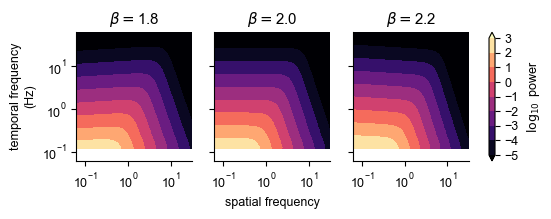

In [249]:
fig, axs = plt.subplots(1, 4, figsize=(0.8*fw, 0.6 * hw), width_ratios=[1, 1, 1, 0.05])

betas = [1.8, 2.0, 2.2]
D = 0.5

levels = np.linspace(-5, 3, 9)
cf = None

for i, beta in enumerate(betas):
    Cx = Cx_separable_drift(k, w, D, alpha=beta)
    ax = axs[i]
    cf = ax.contourf(
        k,
        w_plot,
        np.log10(Cx).T,
        levels=levels,
        cmap="magma",
        extend="both",
        # rasterized=True
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.minorticks_off()
    ax.set_xlim(k.min(), k.max())
    ax.set_ylim(w_plot.min(), w_plot.max())
    
    ax.set_title(f"$\\beta =${beta:.1f}")

    if i != 0:
        ax.set_yticklabels([])
        ax.set_ylabel("")
    else:
        ax.set_ylabel("temporal frequency\n(Hz)")
    ax.set_aspect("equal")
axs[1].set_xlabel("spatial frequency")
# Add colorbar to the last subplot
cbar = plt.colorbar(cf, cax=axs[-1], fraction=0.046, pad=0.04, label="$\log_{10}$ power")
plt.tight_layout()
# axs[-1].set_ylabel("")  # Remove y label from the colorbar axis (optional)
# axs[-1].set_yticks([])  # Remove ticks from colorbar axis itself (optional)
plt.savefig("../results/spatial_temporal_spectra_for_different_betas.pdf")

In [250]:
Cx

array([[           inf, 8.86929594e+02, 9.00672275e+01, ...,
        1.03040924e-06, 1.02376990e-06, 1.01718619e-06],
       [           inf, 7.69401980e+02, 7.83389525e+01, ...,
        8.97023335e-07, 8.91243451e-07, 8.85512000e-07],
       [           inf, 6.98823152e+02, 7.19620594e+01, ...,
        8.27152266e-07, 8.21822589e-07, 8.16537574e-07],
       ...,
       [           inf, 1.60160981e-05, 6.50455580e-06, ...,
        4.76076800e-09, 4.74836037e-09, 4.73600808e-09],
       [           inf, 1.58848705e-05, 6.45126087e-06, ...,
        4.72235327e-09, 4.71004803e-09, 4.69779770e-09],
       [           inf, 1.57549716e-05, 6.39850552e-06, ...,
        4.68431819e-09, 4.67211431e-09, 4.65996488e-09]], shape=(512, 513))

* What does the optimal filter look like for a given noise 
* MI curve for differnt models
    * How do the filters change? 

In [31]:
sigma_in  = 0.1
sigma_out = 2.0
K         = 1024
T         = 1024
dx        = 0.1
dt        = 0.005
D         = 5
alpha     = 2.0
c         = 0

# One-sided Fourier grids.
# Drop spatial DC because C_s(k) = k^{-alpha} diverges at k = 0.
k = 2 * np.pi * np.fft.rfftfreq(K, d=dx)[1:]
w = 2 * np.pi * np.fft.rfftfreq(T, d=dt)
w_plot = w.copy()
w_plot[0] = w[1] / 2

wk = one_sided_weights(K, drop_dc=True)
ww = one_sided_weights(T, drop_dc=False)

print(f"min,max temporal frequency: {w.min():.2f}, {w.max():.2f}")
print(f"min,max spatial frequency: {k.min():.2f}, {k.max():.2f}")

weights = wk[:, None] * ww[None, :]
N_eff = np.sum(weights)

all_MI_vals = []
sigma_ins  = [0.05, 0.1, 0.2]
D_vals = np.logspace(-2, 3, 20)
for i,sigma_in in tqdm(enumerate(sigma_ins)):
    MI_vals = []
    for j,D in enumerate(D_vals):
        Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha,c=c)
        MI_vals.append(MI)
    all_MI_vals.append(MI_vals)

min,max temporal frequency: 0.00, 628.32
min,max spatial frequency: 0.06, 31.42


0it [00:00, ?it/s]

3it [00:04,  1.40s/it]


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_78513/920690387.py:20: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cax = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_78513/920690387.py:46: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_78513/920690387.py:60: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(w.min(),w.max())
/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_78513/920690387.py:80: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(


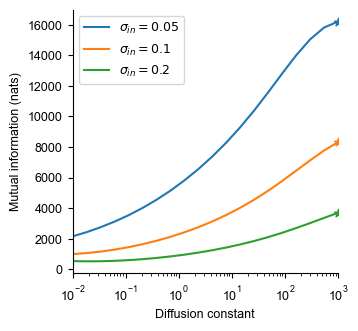

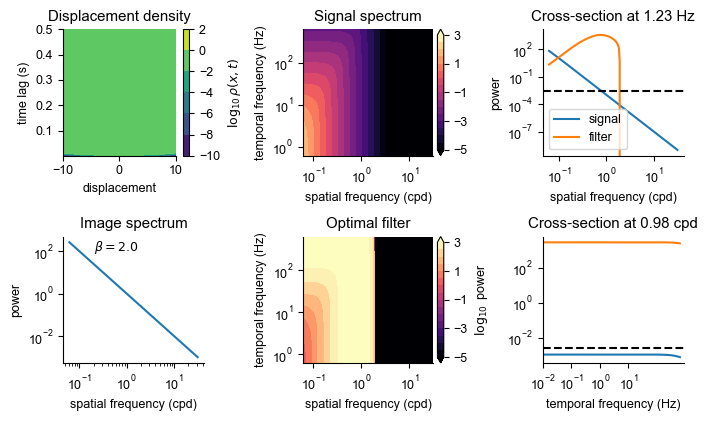

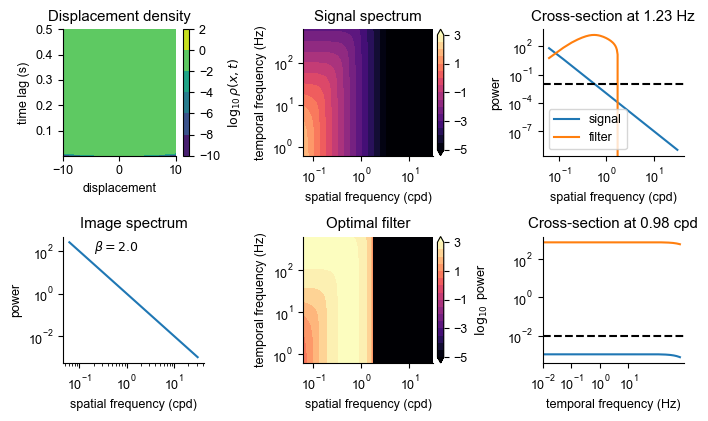

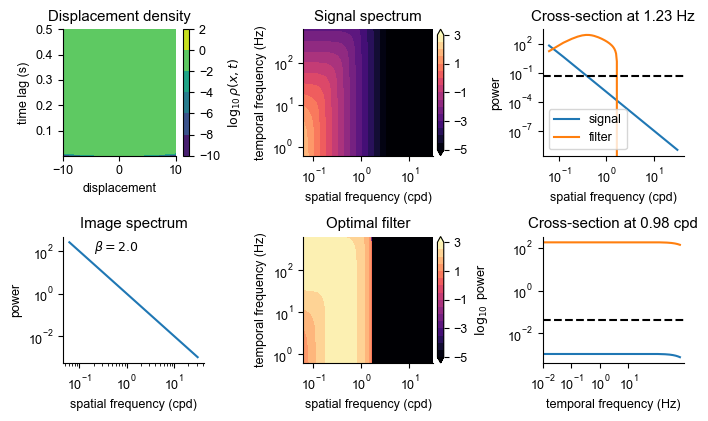

In [32]:
fig,ax = plt.subplots(figsize=(hw,hw))

for i,MI_vals in enumerate(all_MI_vals):
    ax.plot(D_vals, MI_vals, label=rf'$\sigma_{{in}} = {sigma_ins[i]}$', color=f'C{i}')
    ax.scatter(D_vals[np.argmax(MI_vals)], np.max(MI_vals),marker="*", color=f'C{i}')
    Cx, v_opt, MI = mutual_information(k, w, weights, D_vals[np.argmax(MI_vals)], sigma_ins[i], sigma_out, alpha,c=c)
    plot_model(
        Cx, v_opt, sigma_ins[i], sigma_out, K, T, dx, dt, D_vals[np.argmax(MI_vals)], alpha, k, w, w_plot,n=2,levels=np.linspace(-5, 3, 17)
    )
    # ax.text(D_vals[np.argmax(MI_vals)], np.max(MI_vals), f'$\sigma_{{in}} = {sigma_ins[i]}$',horizontalalignment="center")

# ax.set_xscale('log')
ax.set_xlabel('Diffusion constant')
ax.set_ylabel('Mutual information (nats)')
ax.set_xscale('log')
# ax.set_ylim(0,1.1e4)
ax.set_xlim(D_vals[0],D_vals[-1])
ax.legend()

In [413]:
all_MI_vals = []
sigma_ins  = [0.01, 0.02, 0.05, 0.1, 0.2]
D_vals = np.logspace(-2, 2, 20)
for i,sigma_in in tqdm(enumerate(sigma_ins)):
    MI_vals = []
    for j,D in enumerate(D_vals):
        Cx, v_opt, MI = mutual_information(k, w, weights, D, sigma_in, sigma_out, alpha)
        MI_vals.append(MI)
    all_MI_vals.append(MI_vals)

5it [00:04,  1.22it/s]


/var/folders/hy/7cxjc3qx1vsfk45ckcv7_w3h0000gn/T/ipykernel_96499/3885071493.py:59: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(w.min(),w.max())


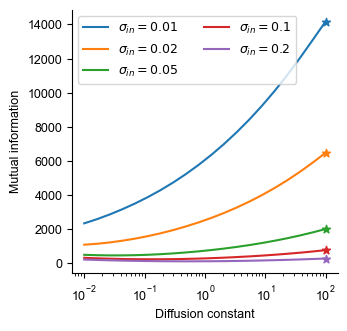

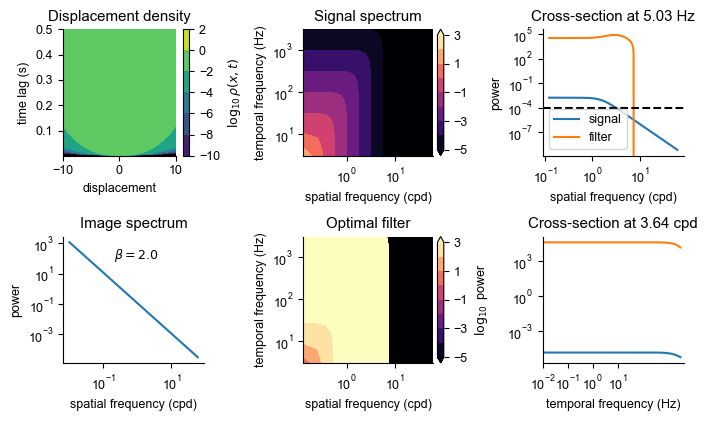

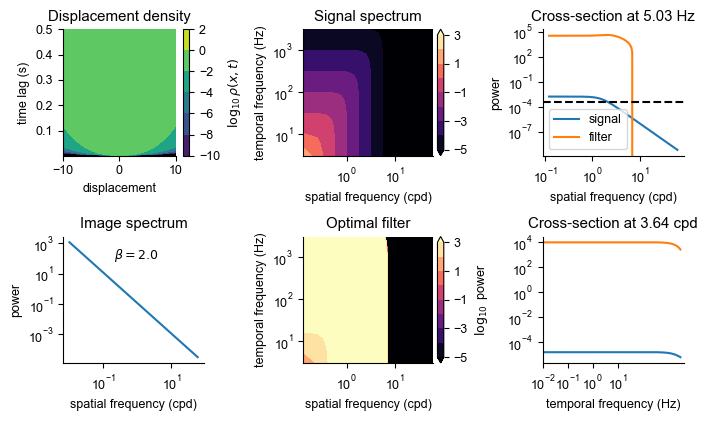

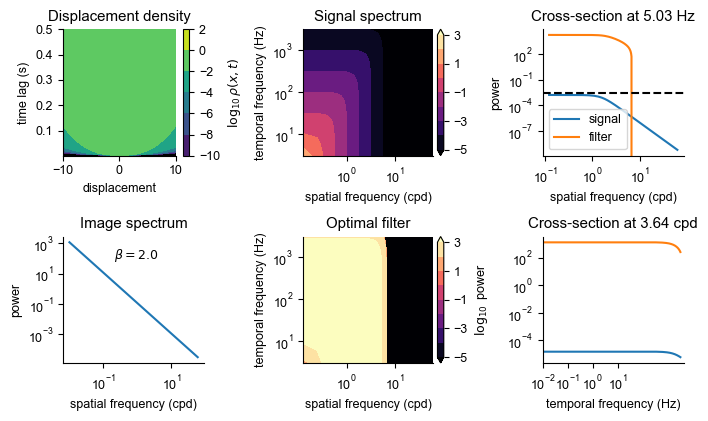

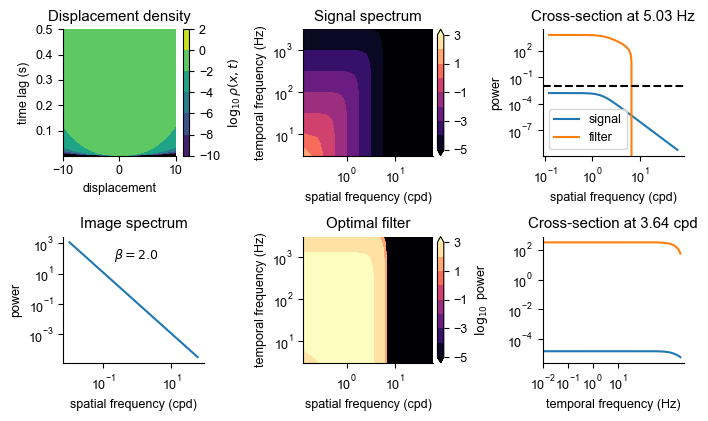

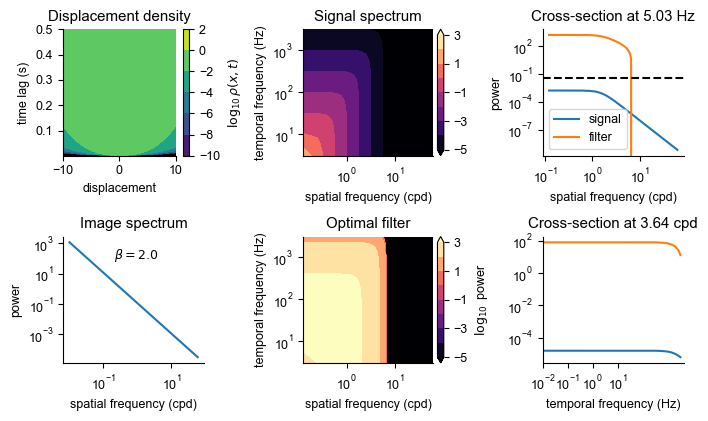

In [414]:
fig,ax = plt.subplots(figsize=(hw,hw))

for i,MI_vals in enumerate(all_MI_vals):
    ax.plot(D_vals, MI_vals, label=rf'$\sigma_{{in}} = {sigma_ins[i]}$', color=f'C{i}')
    ax.scatter(D_vals[np.argmax(MI_vals)], np.max(MI_vals),marker="*", color=f'C{i}')
    Cx, v_opt, MI = mutual_information(k, w, weights, D_vals[np.argmax(MI_vals)], sigma_ins[i], sigma_out, alpha)
    plot_model(
        Cx, v_opt, sigma_ins[i], sigma_out, K, T, dx, dt, D_vals[np.argmax(MI_vals)], alpha, k, w, w_plot
    )

# ax.set_xscale('log')
ax.set_xlabel('Diffusion constant')
ax.set_ylabel('Mutual information')
ax.set_xscale('log')
ax.legend(ncol=2)

x = np.linspace(0,1,100)
S = -2*x + 2.1

a = S/(S+0.2)
b = np.sqrt(1+1/(S))+1
plt.plot(x,S,label="signal")
plt.plot(x,a,label="filter")
plt.legend()

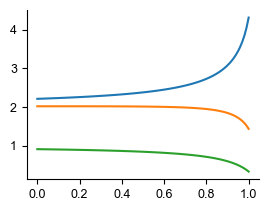

In [322]:
plt.plot(x,b)
plt.plot(x,a*b)
plt.plot(x,a)
# plt.plot(x,S/(S+1))
# plt.plot(x,0.5*S/(S+1)*(np.sqrt(1+1/(S))+1)+1)

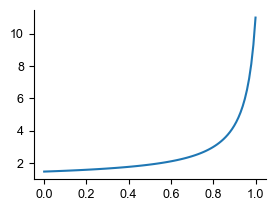

In [302]:
plt.plot(x,1+1/(S))

(480, 720)


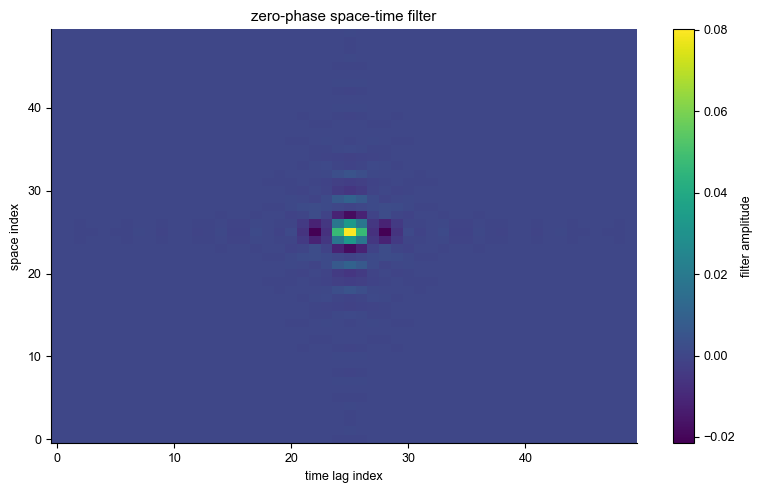

In [119]:
import numpy as np
import matplotlib.pyplot as plt


v_pos = r.v_sq

# Zero-phase amplitude spectrum for positive spatial frequencies
W_pos = np.sqrt(np.maximum(v_pos, 0))

W_full_shifted = np.concatenate(
    [W_pos[::-1, :], W_pos],
    axis=0
)

print(W_full_shifted.shape)  # (240, 720)

# Zero-phase Fourier-domain filter
# W0 = np.sqrt(np.maximum(v, 0))

# If both axes are fftshifted frequency axes, unshift both before ifft2
W0_unshifted = np.fft.ifftshift(W_full_shifted, axes=(0, 1))

# Inverse Fourier transform to space-time
w0_xt = np.fft.ifft2(W0_unshifted).real

# Shift result for visualization so zero space/time is centered
w0_xt_plot = np.fft.fftshift(w0_xt, axes=(0, 1))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    w0_xt_plot[
        w0_xt_plot.shape[0]//2 - 25:w0_xt_plot.shape[0]//2 + 25,
        w0_xt_plot.shape[1]//2 - 25:w0_xt_plot.shape[1]//2 + 25
    ],
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)
fig.colorbar(im, ax=ax, label="filter amplitude")
ax.set_xlabel("time lag index")
ax.set_ylabel("space index")
ax.set_title("zero-phase space-time filter")
plt.tight_layout()
plt.show()


In [120]:
import numpy as np
import matplotlib.pyplot as plt


def minimum_phase_temporal_bank_from_magnitude(mag_centered, eps=1e-12):
    """
    Minimum-phase temporal spectra for a bank of magnitude spectra.

    Parameters
    ----------
    mag_centered : array, shape (n_f, n_tf)
        Temporal magnitude spectra on a centered frequency grid:
        [-tf_max, ..., 0, ..., +tf_max].
    eps : float
        Numerical floor.

    Returns
    -------
    H_centered : complex array, shape (n_f, n_tf)
        Minimum-phase complex spectra on the same centered frequency grid.
    """
    mag_centered = np.asarray(mag_centered, dtype=float)
    mag_centered = np.maximum(mag_centered, eps)

    # Convert centered frequency order to FFT order.
    mag_fft = np.fft.ifftshift(mag_centered, axes=1)

    n_tf = mag_fft.shape[1]
    log_mag = np.log(mag_fft)

    # Real cepstrum.
    cep = np.fft.ifft(log_mag, axis=1).real

    # Minimum-phase cepstrum.
    cep_min = np.zeros_like(cep)
    cep_min[:, 0] = cep[:, 0]

    if n_tf % 2 == 0:
        cep_min[:, 1:n_tf // 2] = 2.0 * cep[:, 1:n_tf // 2]
        cep_min[:, n_tf // 2] = cep[:, n_tf // 2]
    else:
        cep_min[:, 1:(n_tf + 1) // 2] = 2.0 * cep[:, 1:(n_tf + 1) // 2]

    log_H_min = np.fft.fft(cep_min, axis=1)
    H_fft = np.exp(log_H_min)

    # Back to centered temporal-frequency order.
    H_centered = np.fft.fftshift(H_fft, axes=1)
    return H_centered


def spacetime_filter_minphase_time_xt_slice(
    f,
    tf_hz,
    v_sq,
    *,
    tf_min_hz=0.01,
    tf_max_hz=120.0,
    n_tf_uniform=2048,
    f_max=80.0,
    n_space=512,
    floor_rel=1e-4,
):
    """
    Compute an x-t slice through y=0 of the space-time filter.

    Spatial structure:
        zero-phase, radial, 2D spatial spectrum.

    Temporal structure:
        minimum-phase temporal spectrum independently at each radial f.

    Parameters
    ----------
    f : array, shape (n_f,)
        Positive radial spatial-frequency grid, cpd.
    tf_hz : array, shape (n_tf_original,)
        Temporal-frequency grid, containing positive and negative frequencies.
    v_sq : array, shape (n_f, n_tf_original)
        Power spectrum |W(f, tf)|^2.
    tf_min_hz, tf_max_hz : float
        Temporal band limits.
    n_tf_uniform : int
        Number of uniformly spaced temporal-frequency samples.
    f_max : float
        Maximum spatial frequency for the reconstructed spatial grid.
    n_space : int
        Spatial grid size for x and y.
    floor_rel : float
        Relative magnitude floor for cepstral minimum-phase reconstruction.

    Returns
    -------
    x : array, shape (n_space,)
        Space axis, degrees.
    t : array, shape (n_tf_uniform,)
        Time axis, seconds.
    w_xt : array, shape (n_space, n_tf_uniform)
        x-t slice through y=0.
    H_f_tf : complex array, shape (n_f, n_tf_uniform)
        Minimum-phase temporal spectra at each input spatial frequency.
    tf_uniform : array, shape (n_tf_uniform,)
        Centered temporal-frequency grid used for reconstruction.
    """
    if n_space % 2:
        raise ValueError("n_space must be even")
    if n_tf_uniform % 2:
        raise ValueError("n_tf_uniform must be even")

    f = np.asarray(f, dtype=float)
    tf_hz = np.asarray(tf_hz, dtype=float)
    v_sq = np.asarray(v_sq, dtype=float)

    if v_sq.shape != (len(f), len(tf_hz)):
        raise ValueError(
            f"Expected v_sq.shape == ({len(f)}, {len(tf_hz)}), got {v_sq.shape}"
        )

    # Use only positive temporal frequencies from the solved spectrum.
    pos = tf_hz > 0
    tf_pos = tf_hz[pos]
    order = np.argsort(tf_pos)
    tf_pos = tf_pos[order]

    mag_pos = np.sqrt(np.maximum(v_sq[:, pos], 0.0))
    mag_pos = mag_pos[:, order]

    tf_max = min(float(tf_pos.max()), float(tf_max_hz))

    # Centered, uniform temporal-frequency grid.
    tf_uniform = (
        np.arange(int(n_tf_uniform)) - int(n_tf_uniform) // 2
    ) * (2.0 * tf_max / int(n_tf_uniform))

    # Interpolate each spatial-frequency row onto the uniform temporal grid.
    # Magnitude is even in temporal frequency.
    mag_uniform = np.empty((len(f), int(n_tf_uniform)), dtype=float)

    abs_tf = np.abs(tf_uniform)
    for i in range(len(f)):
        mag_uniform[i] = np.interp(
            abs_tf,
            tf_pos,
            mag_pos[i],
            left=mag_pos[i, 0],
            right=0.0,
        )

    # Apply your existing taper if defined.
    taper = soft_band_taper(tf_uniform, tf_min_hz, tf_max)
    mag_uniform *= taper[None, :]

    # Row-wise numerical floor.
    row_max = np.maximum(np.nanmax(mag_uniform, axis=1, keepdims=True), 1e-300)
    mag_uniform = np.maximum(mag_uniform, floor_rel * row_max)

    # Minimum-phase temporal complex spectrum at each radial spatial frequency.
    H_f_tf = minimum_phase_temporal_bank_from_magnitude(mag_uniform)

    # Build 2D spatial-frequency grid.
    df = 2.0 * float(f_max) / int(n_space)
    fx = (np.arange(int(n_space)) - int(n_space) // 2) * df
    fy = fx.copy()
    FX, FY = np.meshgrid(fx, fy, indexing="xy")
    FR = np.sqrt(FX * FX + FY * FY)

    # Physical spatial axis.
    dx = 1.0 / (int(n_space) * df)
    x = (np.arange(int(n_space)) - int(n_space) // 2) * dx
    y = x.copy()
    iy0 = int(np.argmin(np.abs(y)))

    # Temporal axis corresponding to tf_uniform.
    dnu = float(tf_uniform[1] - tf_uniform[0])
    dt = 1.0 / (int(n_tf_uniform) * dnu)
    t = np.arange(int(n_tf_uniform)) * dt

    # For each temporal frequency, lift radial spectrum to 2D,
    # spatial inverse FFT, and keep the y=0 slice.
    w_x_tf_centered = np.empty((int(n_space), int(n_tf_uniform)), dtype=complex)

    for j in range(int(n_tf_uniform)):
        Hj = H_f_tf[:, j]

        # Interpolate complex radial spectrum over |k|.
        Vxy = (
            np.interp(FR, f, Hj.real, left=Hj.real[0], right=0.0)
            +
            1j * np.interp(FR, f, Hj.imag, left=Hj.imag[0], right=0.0)
        )

        # Spatial inverse FFT.
        # Vxy is centered in spatial frequency, so ifftshift before ifft2.
        w_xy = np.fft.fftshift(
            np.fft.ifft2(np.fft.ifftshift(Vxy))
        ) * (int(n_space) * df) ** 2

        w_x_tf_centered[:, j] = w_xy[iy0, :]

    # Temporal inverse FFT.
    # Temporal spectrum is centered, so ifftshift before ifft.
    w_x_t = np.fft.ifft(
        np.fft.ifftshift(w_x_tf_centered, axes=1),
        axis=1,
    ) * (int(n_tf_uniform) * dnu)

    w_x_t = w_x_t.real

    return x, t, w_x_t, H_f_tf, tf_uniform

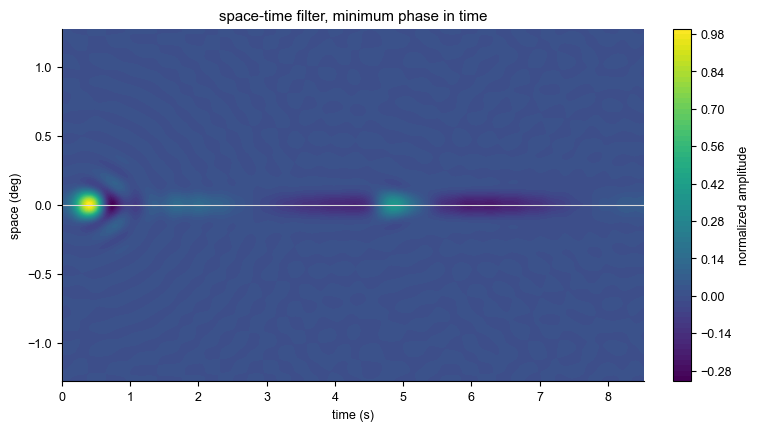

In [125]:

x, t, w_xt, H_f_tf, tf_uniform = spacetime_filter_minphase_time_xt_slice(
    r.f,
    r.tf_hz,
    r.v_sq,
    tf_min_hz=band.tf_min_hz,
    tf_max_hz=band.tf_max_hz,
    n_tf_uniform=2048,
    f_max=band.f_max,
    n_space=512,
    floor_rel=1e-4,
)

# Normalize for visualization.
w_plot = w_xt / max(np.max(np.abs(w_xt)), 1e-300)

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
im = ax.contourf(
    t,
    x,
    w_plot,
    levels=80,
)
fig.colorbar(im, ax=ax, label="normalized amplitude")
ax.axvline(0, color="0.85", lw=0.8)
ax.axhline(0, color="0.85", lw=0.8)
# ax.set_xlim(0, 0.35)
# ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("space (deg)")
ax.set_title(f"space-time filter, minimum phase in time")
plt.show()

In [126]:
import numpy as np
import matplotlib.pyplot as plt


def minimum_phase_temporal_bank_from_magnitude(mag_centered, eps=1e-12):
    """
    Minimum-phase temporal spectra for many spatial-frequency rows.

    mag_centered has shape (n_f, n_tf), with temporal frequency ordered as:
        [-nu_max, ..., 0, ..., +nu_max]
    """
    mag_centered = np.asarray(mag_centered, dtype=float)
    mag_centered = np.maximum(mag_centered, eps)

    # FFT algorithms expect [0, positive freqs, negative freqs].
    mag_fft = np.fft.ifftshift(mag_centered, axes=1)

    n_tf = mag_fft.shape[1]
    log_mag = np.log(mag_fft)

    cep = np.fft.ifft(log_mag, axis=1).real

    cep_min = np.zeros_like(cep)
    cep_min[:, 0] = cep[:, 0]

    if n_tf % 2 == 0:
        cep_min[:, 1:n_tf // 2] = 2.0 * cep[:, 1:n_tf // 2]
        cep_min[:, n_tf // 2] = cep[:, n_tf // 2]
    else:
        cep_min[:, 1:(n_tf + 1) // 2] = 2.0 * cep[:, 1:(n_tf + 1) // 2]

    log_H = np.fft.fft(cep_min, axis=1)
    H_fft = np.exp(log_H)

    # Return to centered temporal-frequency order.
    H_centered = np.fft.fftshift(H_fft, axes=1)
    return H_centered


def spacetime_filter_1d_space_minphase_time(
    f,
    tf_hz,
    v_sq,
    *,
    tf_min_hz=0.01,
    tf_max_hz=120.0,
    n_tf_uniform=2048,
    f_max=None,
    n_f_uniform=512,
    floor_rel=1e-4,
):
    """
    Compute a 1D space-time filter w(x,t).

    Assumptions
    -----------
    v_sq has shape (n_f, n_tf).
    f is positive spatial frequency only.
    tf_hz contains both positive and negative temporal frequencies.
    Temporal phase is minimum phase.
    Spatial phase is zero phase.
    """
    if n_tf_uniform % 2:
        raise ValueError("n_tf_uniform must be even")
    if n_f_uniform % 2:
        raise ValueError("n_f_uniform must be even")

    f = np.asarray(f, dtype=float)
    tf_hz = np.asarray(tf_hz, dtype=float)
    v_sq = np.asarray(v_sq, dtype=float)

    if v_sq.shape != (len(f), len(tf_hz)):
        raise ValueError(
            f"Expected v_sq.shape == ({len(f)}, {len(tf_hz)}), got {v_sq.shape}"
        )

    if f_max is None:
        f_max = float(np.nanmax(f))

    # ----------------------------
    # 1. Build uniform temporal grid
    # ----------------------------
    pos_t = tf_hz > 0
    tf_pos = tf_hz[pos_t]
    order_t = np.argsort(tf_pos)
    tf_pos = tf_pos[order_t]

    mag_pos_t = np.sqrt(np.maximum(v_sq[:, pos_t], 0.0))
    mag_pos_t = mag_pos_t[:, order_t]

    tf_max_eff = min(float(tf_pos.max()), float(tf_max_hz))

    tf_uniform = (
        np.arange(n_tf_uniform) - n_tf_uniform // 2
    ) * (2.0 * tf_max_eff / n_tf_uniform)

    abs_tf = np.abs(tf_uniform)

    mag_f_tf = np.empty((len(f), n_tf_uniform), dtype=float)

    for i in range(len(f)):
        mag_f_tf[i] = np.interp(
            abs_tf,
            tf_pos,
            mag_pos_t[i],
            left=mag_pos_t[i, 0],
            right=0.0,
        )

    # Optional temporal taper, using your existing function.
    taper = soft_band_taper(tf_uniform, tf_min_hz, tf_max_eff)
    mag_f_tf *= taper[None, :]

    # Row-wise floor for stable log magnitude.
    row_max = np.maximum(np.nanmax(mag_f_tf, axis=1, keepdims=True), 1e-300)
    mag_f_tf = np.maximum(mag_f_tf, floor_rel * row_max)

    # ----------------------------
    # 2. Minimum-phase in time for each positive spatial frequency
    # ----------------------------
    H_pos_f_tf = minimum_phase_temporal_bank_from_magnitude(mag_f_tf)

    # ----------------------------
    # 3. Interpolate to uniform positive spatial-frequency grid
    # ----------------------------
    f_pos_uniform = np.linspace(0.0, float(f_max), n_f_uniform // 2 + 1)

    H_pos_uniform = np.empty(
        (len(f_pos_uniform), n_tf_uniform),
        dtype=complex,
    )

    for j in range(n_tf_uniform):
        H_pos_uniform[:, j] = (
            np.interp(
                f_pos_uniform,
                f,
                H_pos_f_tf[:, j].real,
                left=H_pos_f_tf[0, j].real,
                right=0.0,
            )
            +
            1j * np.interp(
                f_pos_uniform,
                f,
                H_pos_f_tf[:, j].imag,
                left=H_pos_f_tf[0, j].imag,
                right=0.0,
            )
        )

    # ----------------------------
    # 4. Mirror positive spatial frequencies to negative spatial frequencies
    # ----------------------------
    # H_pos_uniform contains [0, ..., f_Nyquist].
    # Full centered spatial spectrum should be:
    # [-f_Nyquist, ..., -df, 0, df, ..., f_Nyquist-df]
    #
    # For an even-length FFT grid, do not duplicate the positive Nyquist endpoint.
    H_spatial_centered = np.concatenate(
        [
            H_pos_uniform[-1:0:-1, :],
            H_pos_uniform[:-1, :],
        ],
        axis=0,
    )

    # Now H_spatial_centered has shape (n_f_uniform, n_tf_uniform).
    # Spatial axis is centered. Temporal axis is centered.

    # ----------------------------
    # 5. Inverse FFT over space and time
    # ----------------------------
    H_fft_order = np.fft.ifftshift(H_spatial_centered, axes=(0, 1))

    w_x_t = np.fft.ifft2(H_fft_order).real

    # Center space for plotting.
    # Do NOT center time if you want minimum-phase/causal-looking time.
    w_x_t = np.fft.fftshift(w_x_t, axes=0)

    # Axes
    df = 2.0 * float(f_max) / n_f_uniform
    dx = 1.0 / (n_f_uniform * df)
    x = (np.arange(n_f_uniform) - n_f_uniform // 2) * dx

    dnu = float(tf_uniform[1] - tf_uniform[0])
    dt = 1.0 / (n_tf_uniform * dnu)
    t = np.arange(n_tf_uniform) * dt

    return x, t, w_x_t, H_spatial_centered, tf_uniform

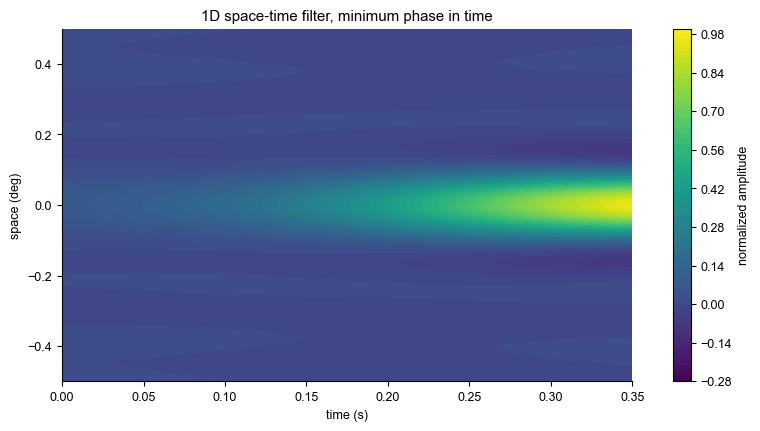

In [127]:
ri = r

x, t, w_xt, H_f_tf, tf_uniform = spacetime_filter_1d_space_minphase_time(
    ri.f,
    ri.tf_hz,
    ri.v_sq,
    tf_min_hz=band.tf_min_hz,
    tf_max_hz=band.tf_max_hz,
    n_tf_uniform=2048,
    f_max=band.f_max,
    n_f_uniform=512,
    floor_rel=1e-4,
)

w_plot = w_xt / max(np.max(np.abs(w_xt)), 1e-300)

fig, ax = plt.subplots(figsize=(7.5, 4.2), constrained_layout=True)
im = ax.contourf(
    t,
    x,
    w_plot,
    levels=80,
)
fig.colorbar(im, ax=ax, label="normalized amplitude")
ax.set_xlim(0, 0.35)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("space (deg)")
ax.set_title(f"1D space-time filter, minimum phase in time")
plt.show()

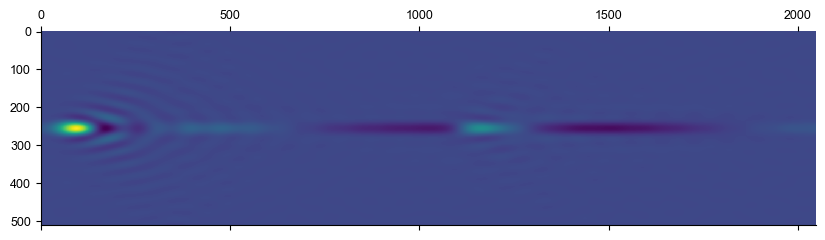

In [128]:
fig,ax = plt.subplots(figsize=(10,10))
ax.matshow(w_plot)

In [24]:
import numpy as np
import matplotlib.pyplot as plt


def minimum_phase_from_power_spectrum(
    v,
    axis=-1,
    eps=1e-12,
    freq_shifted=True,
):
    """
    Construct a minimum-phase temporal filter from a power spectrum v(k, omega).

    Parameters
    ----------
    v : array
        Power spectrum, e.g. shape (n_k, n_omega).
        Assumes v = |W|^2.
    axis : int
        Axis corresponding to temporal frequency.
    eps : float
        Small floor to avoid log(0).
    freq_shifted : bool
        True if temporal frequency axis is fftshifted, i.e. ordered
        [-omega_max, ..., 0, ..., +omega_max].
        False if axis is in standard FFT order:
        [0, +freqs..., -freqs...].

    Returns
    -------
    H_min : complex array
        Minimum-phase temporal transfer function, same shape as v.
    h_min : real array
        Minimum-phase temporal impulse response, same shape as v.
    """

    v = np.asarray(v, dtype=float)

    # Move temporal-frequency axis to the end.
    v_work = np.moveaxis(v, axis, -1)

    # Convert from power to amplitude.
    amp = np.sqrt(np.maximum(v_work, eps))

    # Minimum-phase spectral factorization assumes standard FFT frequency order.
    # If your frequency axis is fftshifted, unshift it first.
    if freq_shifted:
        amp_fft_order = np.fft.ifftshift(amp, axes=-1)
    else:
        amp_fft_order = amp

    n = amp_fft_order.shape[-1]

    # Log amplitude.
    log_amp = np.log(np.maximum(amp_fft_order, eps))

    # Real cepstrum of log amplitude.
    cep = np.fft.ifft(log_amp, axis=-1).real

    # Minimum-phase cepstrum:
    # keep zero quefrency, double positive quefrencies,
    # zero negative quefrencies.
    cep_min = np.zeros_like(cep)
    cep_min[..., 0] = cep[..., 0]

    if n % 2 == 0:
        # Even length: Nyquist term is its own conjugate, keep it once.
        cep_min[..., 1:n//2] = 2.0 * cep[..., 1:n//2]
        cep_min[..., n//2] = cep[..., n//2]
    else:
        cep_min[..., 1:(n+1)//2] = 2.0 * cep[..., 1:(n+1)//2]

    # Complex log spectrum of the minimum-phase filter.
    log_H_min = np.fft.fft(cep_min, axis=-1)

    # Minimum-phase transfer function.
    H_min_fft_order = np.exp(log_H_min)

    # Temporal impulse response.
    h_min = np.fft.ifft(H_min_fft_order, axis=-1).real

    # Return H in the same frequency ordering as input.
    if freq_shifted:
        H_min = np.fft.fftshift(H_min_fft_order, axes=-1)
    else:
        H_min = H_min_fft_order

    # Move temporal axis back.
    H_min = np.moveaxis(H_min, -1, axis)
    h_min = np.moveaxis(h_min, -1, axis)

    return H_min, h_min

# v has shape (120, 720)
H_min, w_k_t = minimum_phase_from_power_spectrum(
    v,
    axis=1,
    eps=1e-12,
    freq_shifted=True,   # set False if v is already in np.fft.fftfreq ordering
)

print(H_min.shape)  # (120, 720)
print(w_k_t.shape)  # (120, 720)

(120, 720)
(120, 720)


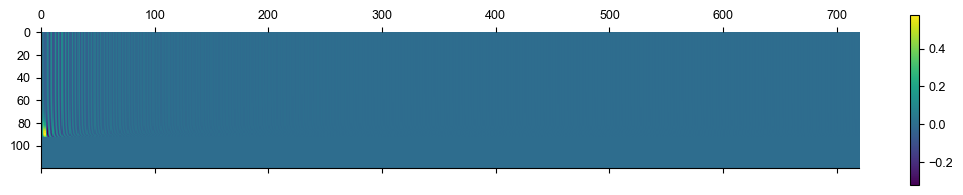

In [31]:
plt.matshow(w_k_t)
plt.colorbar()

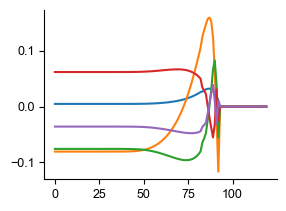

In [33]:
plt.plot(w_k_t[:,np.arange(0,50,10)])

In [14]:
r.v_sq

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(120, 720))

In [12]:
r.f, r.tf_hz, r.v_sq

(array([1.00000000e-02, 1.08047182e-02, 1.16741936e-02, 1.26136372e-02,
        1.36286796e-02, 1.47254043e-02, 1.59103844e-02, 1.71907220e-02,
        1.85740907e-02, 2.00687817e-02, 2.16837531e-02, 2.34286842e-02,
        2.53140332e-02, 2.73510995e-02, 2.95520924e-02, 3.19302031e-02,
        3.44996847e-02, 3.72759372e-02, 4.02755998e-02, 4.35166507e-02,
        4.70185149e-02, 5.08021805e-02, 5.48903245e-02, 5.93074490e-02,
        6.40800274e-02, 6.92366640e-02, 7.48082646e-02, 8.08282219e-02,
        8.73326162e-02, 9.43604310e-02, 1.01953787e-01, 1.10158194e-01,
        1.19022824e-01, 1.28600808e-01, 1.38949549e-01, 1.50131073e-01,
        1.62212394e-01, 1.75265921e-01, 1.89369889e-01, 2.04608829e-01,
        2.21074074e-01, 2.38864308e-01, 2.58086154e-01, 2.78854817e-01,
        3.01294772e-01, 3.25540512e-01, 3.51737350e-01, 3.80042296e-01,
        4.10624992e-01, 4.43668733e-01, 4.79371565e-01, 5.17947468e-01,
        5.59627645e-01, 6.04661901e-01, 6.53320146e-01, 7.058940

Text(0.5, 0.98, 'signal spectra C(f,ν), normalized per panel')

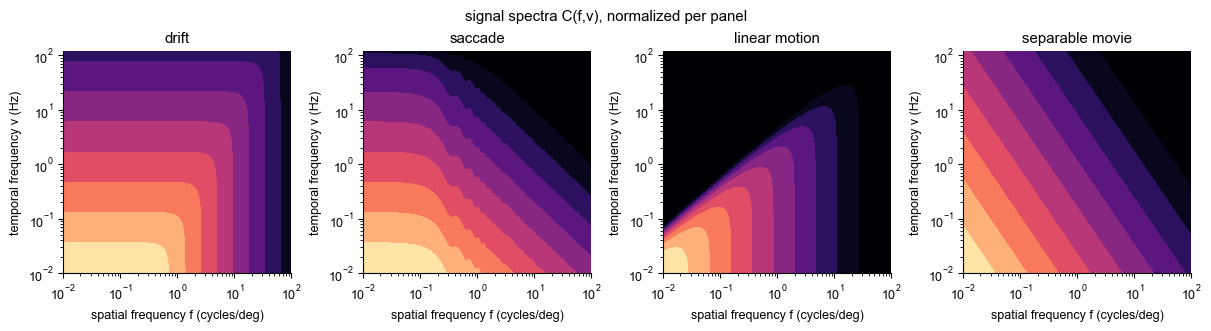

In [9]:
fig, axes = plt.subplots(1, len(spectra), figsize=(3.0 * len(spectra), 3.2), constrained_layout=True)
for ax, (name, spec) in zip(axes, spectra):
    panel_loglog(
        ax, f, tf_hz, spec.C(f, tf_hz),
        f_min=band.f_min, f_max=band.f_max,
        tf_min_hz=band.tf_min_hz, tf_max_hz=band.tf_max_hz,
        cmap="magma", normalize=True, label=name,
        floor_rel=1e-10, n_levels=10,
    )
fig.suptitle("signal spectra C(f,ν), normalized per panel")


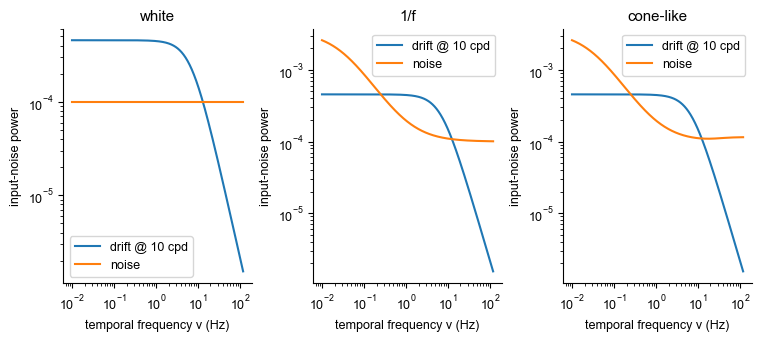

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(7.5, 3.3), constrained_layout=True)
tf_pos = np.geomspace(band.tf_min_hz, band.tf_max_hz, 600)
for name, ax, noise in [("white", axs[0], white_noise), ("1/f", axs[1], powerlaw_noise), ("cone-like", axs[2], cone_noise)]:
    ax.plot(tf_pos, drift.C(10*np.ones_like(tf_pos), tf_pos)[0], label="drift @ 10 cpd")
    ax.plot(tf_pos, noise.power(np.array([1.0]), tf_pos)[0], label='noise')
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    ax.set_xlabel("temporal frequency ν (Hz)")
    ax.set_ylabel("input-noise power")
    ax.set_title(name)


information I = 283.337 nats
lambda        = 238.581
budget spend  = 1 / P0=1


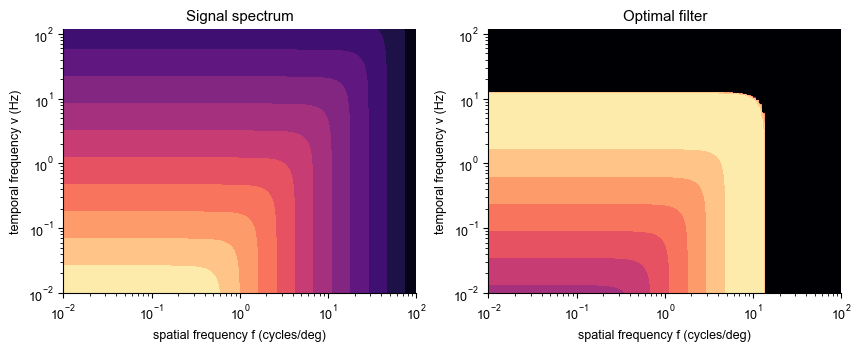

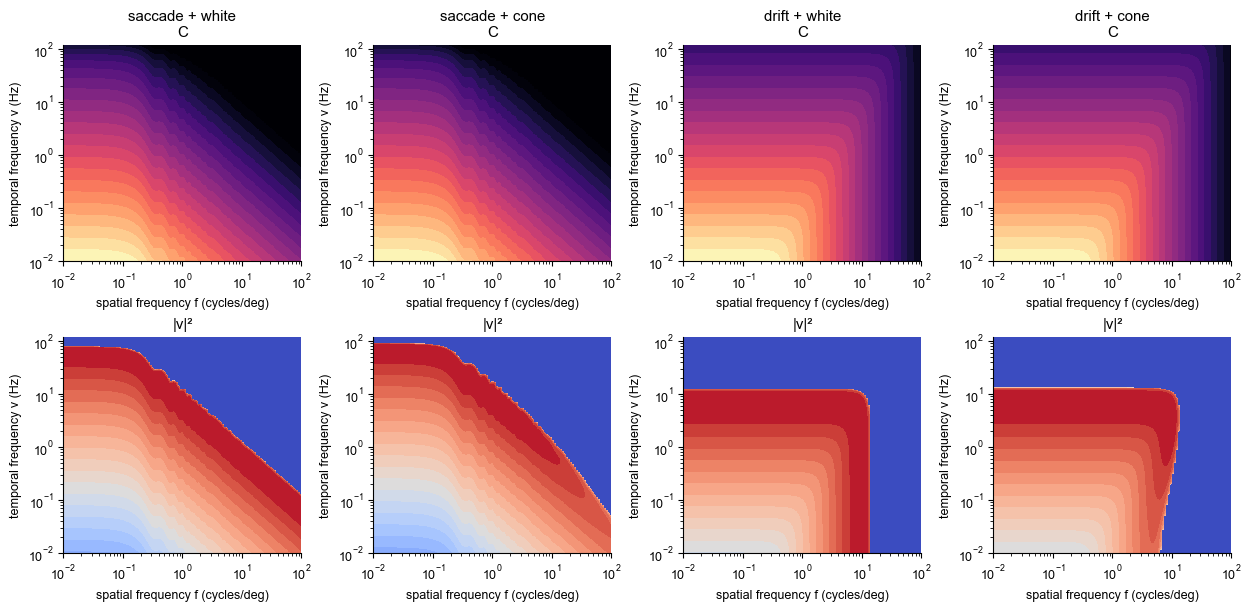

In [21]:
cases = [
    ("saccade + white", saccade, white_noise),
    ("saccade + cone", saccade, cone_noise),
    ("drift + white", drift, white_noise),
    ("drift + cone", drift, cone_noise),
]

fig, axes = plt.subplots(2, len(cases), figsize=(3.1 * len(cases), 6.0), constrained_layout=True)
results = []
for j, (name, spec_i, noise_i) in enumerate(cases):
    ri = solve_on_grid(spec_i, f, tf_hz, P0=P0, input_noise=noise_i, output_noise=output_noise, band=band.edges)
    results.append((name, ri))
    panel_loglog(axes[0, j], f, tf_hz, ri.C, f_min=band.f_min, f_max=band.f_max, tf_min_hz=band.tf_min_hz, tf_max_hz=band.tf_max_hz, cmap="magma", normalize=True, label=name + "\nC")
    panel_loglog(axes[1, j], f, tf_hz, ri.v_sq, f_min=band.f_min, f_max=band.f_max, tf_min_hz=band.tf_min_hz, tf_max_hz=band.tf_max_hz, cmap="coolwarm", normalize=True, label="|v|²")


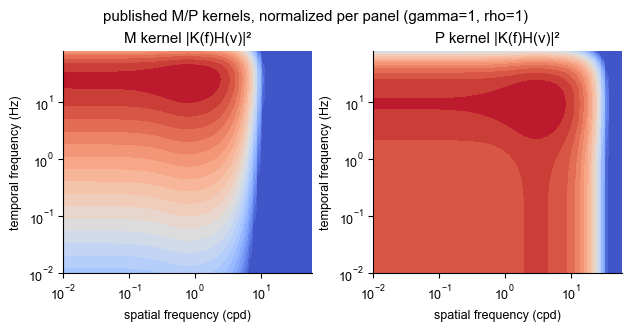

In [457]:
mp_gamma = 1.0
mp_rho = 1.0
fig, axes = plt.subplots(1, 2, figsize=(6.2, 3.2), constrained_layout=True)
for ax, cell in zip(axes, ["M", "P"]):
    panel_loglog(
        ax,
        f,
        tf_hz,
        mp_filter_power(f, tf_hz, cell, gamma=mp_gamma, rho=mp_rho),
        f_min=band.f_min,
        f_max=band.f_max,
        tf_min_hz=band.tf_min_hz,
        tf_max_hz=band.tf_max_hz,
        cmap="coolwarm",
        normalize=True,
        label=f"{cell} kernel |K(f)H(ν)|²",
    )
fig.suptitle(f"published M/P kernels, normalized per panel (gamma={mp_gamma:g}, rho={mp_rho:g})")
plt.savefig("../results/mp_kernels.pdf")


representative slice frequencies for drift + white: f0=10 cpd, ν0=7 Hz


Text(0.5, 1.0, 'minimum-phase temporal slice at f≈10 cpd')

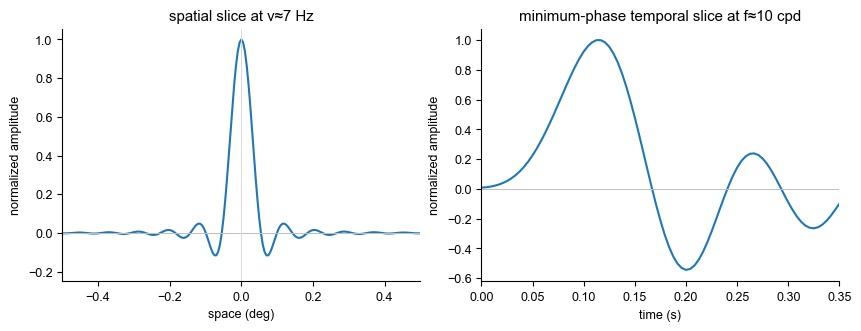

In [23]:
# Spatial: zero phase, centered at x=0.
# Temporal: minimum phase, using the Hilbert/cepstrum construction.
name, ri = results[2]  # edit this index or use r from the single-solve cell
f0 = 10
tf0 = 7
print(f"representative slice frequencies for {name}: f0={f0:.3g} cpd, ν0={tf0:.3g} Hz")

x, spatial_slice, spatial_image = spatial_kernel_slice(ri.f, ri.tf_hz, ri.v_sq, tf0, f_max=band.f_max, n=512)
t, temporal_slice, temporal_spectrum, tf_uniform = temporal_kernel_slice(
    ri.f, ri.tf_hz, ri.v_sq, f0,
    tf_min_hz=band.tf_min_hz,
    tf_max_hz=band.tf_max_hz,
    n_uniform=4096,
)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), constrained_layout=True)
axes[0].plot(x, spatial_slice / max(np.max(np.abs(spatial_slice)), 1e-300))
axes[0].axhline(0, color="0.75", lw=0.7)
axes[0].axvline(0, color="0.85", lw=0.7)
axes[0].set_xlim(-.5, .5)
axes[0].set_ylim(-.25)
axes[0].set_xlabel("space (deg)")
axes[0].set_ylabel("normalized amplitude")
axes[0].set_title(f"spatial slice at ν≈{tf0:.2g} Hz")

axes[1].plot(t, temporal_slice / max(np.max(np.abs(temporal_slice)), 1e-300))
axes[1].axhline(0, color="0.75", lw=0.7)
axes[1].set_xlim(0, 0.35)
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("normalized amplitude")
axes[1].set_title(f"minimum-phase temporal slice at f≈{f0:.2g} cpd")


In [ ]:

fig, ax = plt.subplots(1, len(results),figsize=(10.4, 3.5), constrained_layout=True)
for j, (name, r) in enumerate(results):
    info_density = mutual_information_density(r.C, r.v_sq, r.input_noise_power, r.output_noise_power)
    panel_loglog(
        ax[j], f, tf_hz, info_density,
        f_min=band.f_min, f_max=band.f_max,
        tf_min_hz=band.tf_min_hz, tf_max_hz=band.tf_max_hz,
        cmap="viridis", normalize=True, label="information density",
    )
